# 1. Análisis exploratorio de variables clínicas y mutacionales asociadas a la clasificación histológica (LGG vs. GBM)

## 1.1 Carga de datos y Estructura

### Librerías

In [1]:
# Librerias
## Librerías estándar de Python
import base64
import io
import warnings
import pickle

## Librerías de terceros: NumPy y Pandas
import numpy as np
import pandas as pd

## Visualización
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

## Estadística
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu

## Machine Learning
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Jupyter
from IPython.display import HTML, display
import ipywidgets as widgets
from IPython.display import display
from itables import show

## Configuración de warnings
warnings.filterwarnings("ignore")

# Configuracion visual
PALETTE_GRADE = {0: "#2E86AB", 1: "#C1443C"}

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

### Dataset

El conjunto de datos utilizado para el análisis es `TCGA_InfoWithGrade.csv`,
correspondiente a una versión preprocesada de los datos relacionados con
gliomas del proyecto The Cancer Genome Atlas (TCGA).

In [3]:
df_mutations = pd.read_csv("dataset/TCGA_InfoWithGrade.csv")
df_mutations.head()

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,0,51.30,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0
1,0,0,38.72,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,35.17,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,32.78,0,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0
4,0,0,31.51,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [4]:
df_mutations.tail()

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
834,1,1,77.89,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
835,1,0,85.18,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
836,1,1,77.49,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
837,1,0,63.33,0,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0
838,1,0,76.61,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### Estructura

In [5]:
print(f"Dimensiones del dataset: {df_mutations.shape[0]} pacientes x {df_mutations.shape[1]} variables")
print(f"Registros duplicados: {df_mutations.duplicated().sum()}")
print(f"Valores faltantes: {df_mutations.isnull().sum().sum()}")

Dimensiones del dataset: 839 pacientes x 24 variables
Registros duplicados: 1
Valores faltantes: 0


In [6]:
info_df = pd.DataFrame({
    "Tipo de dato": df_mutations.dtypes.astype(str),
    "Valores no nulos": df_mutations.notna().sum().values,
    "Valores nulos": df_mutations.isna().sum().values,
    "Valores únicos": df_mutations.nunique()
})

info_df = info_df.reset_index().rename(columns={"index": "Columna"})

(
    info_df.style
    .background_gradient(cmap="Reds", subset=["Valores nulos"])
    .bar(subset=["Valores únicos"], color="#5fba7d")
    .set_caption("Resumen Estructural del Dataset")
    .set_properties(**{"font-weight": "bold"}, subset=["Columna"])
)

,Columna,Tipo de dato,Valores no nulos,Valores nulos,Valores únicos
0,Grade,int64,839,0,2
1,Gender,int64,839,0,2
2,Age_at_diagnosis,float64,839,0,766
3,Race,int64,839,0,4
4,IDH1,int64,839,0,2
5,TP53,int64,839,0,2
6,ATRX,int64,839,0,2
7,PTEN,int64,839,0,2
8,EGFR,int64,839,0,2
9,CIC,int64,839,0,2


In [7]:
columnas_categoricas = df_mutations.columns.difference(["Age_at_diagnosis"])
df_mutations[columnas_categoricas] = df_mutations[columnas_categoricas].astype("category")

pd.DataFrame({
    "Tipo": df_mutations.dtypes.astype(str)
}).T

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
Tipo,category,category,float64,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category


El conjunto de datos presenta una estructura limpia y estructurada, compuesta por **839 registros** (pacientes) y **24 variables**, sin presencia de valores nulos o faltantes. Aunque se presente un registro duplicado, este representa a dos pacientes distintos que casualmente comparten el mismo fenotipo y perfil genético, ya que su ID es distinto en el dataset original (`TCGA_GBM_LGG_Mutations_all`). 

Las variables binarias, originalmente codificadas mediante valores enteros `0` y `1`, fueron transformadas al tipo categórico (`category`) para representar adecuadamente su naturaleza y facilitar su análisis exploratorio.

## 1.2 Contexto de los datos

| Categoría | Variables | Codificación |
|---|---|---|
| **Variable objetivo** | `Grade` | 0 = LGG (glioma de bajo grado), 1 = GBM (glioblastoma) |
| **Demográficas** | `Gender`, `Age_at_diagnosis`, `Race` | `Gender`: 0/1; `Race`: 0–3 (categorías étnicas codificadas); `Age`: continua (años) |
| **Mutacionales** | 20 genes (`IDH1`, `TP53`, `ATRX`, `PTEN`, `EGFR`, `CIC`, `MUC16`, `PIK3CA`, `NF1`, `PIK3R1`, `FUBP1`, `RB1`, `NOTCH1`, `BCOR`, `CSMD3`, `SMARCA4`, `GRIN2A`, `IDH2`, `FAT4`, `PDGFRA`) | 0 = no mutado, 1 = mutado |

### Variable Objetivo

- **`Grade`**: Indica el grado del glioma (0 = `LGG`, 1 = `GBM`). Esta variable distingue entre los dos grupos principales del conjunto de datos: Glioma de Bajo Grado (*Low-Grade Glioma*) y Glioblastoma Multiforme (*Glioblastoma Multiforme*).

---

### Variables Clínicas

Proporcionan información sobre las características demográficas de los pacientes:

- **`Gender`**: Género del paciente (0 = masculino, 1 = femenino).
- **`Age_at_diagnosis`**: Edad del paciente al momento del diagnóstico expresada en años (numérica continua). La parte decimal incorpora la información exacta de los días transcurridos.
- **`Race`**: Raza reportada del paciente codificada del 0 al 3 (0 = *White*, 1 = *Black or African American*, 2 = *Asian*, 3 = *American Indian or Alaska Native*).

---


### Variables genéticas

El conjunto de datos también contiene variables correspondientes a
diferentes genes. Estas variables están codificadas de forma binaria,
indicando con un valor de **1** la presencia de una mutación en el gen
correspondiente, y con un **0** la condición de gen salvaje / no mutado (*wildtype*):

- **`IDH1`**: Codifica una enzima involucrada en el metabolismo celular.

- **`TP53`**: Gen supresor tumoral que participa en el control del ciclo celular y en la respuesta al daño del ADN. Sus alteraciones favorecen la proliferación tumoral.

- **`ATRX`**: Participa en el mantenimiento de la estructura de la
  cromatina y en la estabilidad del genoma.

- **`PTEN`**: Gen supresor tumoral que regula vías relacionadas con el
  crecimiento y la supervivencia celular.

- **`EGFR`**: Codifica un receptor involucrado en señales de crecimiento y proliferación celular.

- **`CIC`**: Participa en la regulación de la expresión de otros genes y en procesos relacionados con el desarrollo celular.

- **`MUC16`**: Codifica una proteína de gran tamaño asociada a la
  superficie celular.

- **`PIK3CA`**: Participa en la vía de señalización PI3K/AKT, relacionada con crecimiento, supervivencia y proliferación celular.

- **`NF1`**: Actúa como regulador negativo de señales relacionadas con el crecimiento celular. Sus alteraciones pueden contribuir a la proliferación tumoral.

- **`PIK3R1`**: Codifica una subunidad reguladora de la vía PI3K, que
  interviene en procesos de crecimiento y supervivencia celular.

- **`FUBP1`**: Participa en la regulación de la expresión génica y del
  crecimiento celular.

- **`RB1`**: Gen supresor tumoral que participa en el control del ciclo celular y regula la progresión de las células hacia la división.

- **`NOTCH1`**: Forma parte de la vía de señalización Notch, relacionada con la diferenciación, proliferación y supervivencia celular.

- **`BCOR`**: Participa en la regulación de la expresión génica mediante complejos relacionados con la cromatina.

- **`CSMD3`**: Codifica una proteína de gran tamaño y se encuentra entre los genes que pueden presentar mutaciones en distintos tumores.

- **`SMARCA4`**: Participa en la remodelación de la cromatina y, por
  tanto, en la regulación de la expresión de los genes.

- **`GRIN2A`**: Codifica una subunidad de un receptor de glutamato,
  relacionado principalmente con la señalización neuronal.

- **`IDH2`**: Codifica una enzima metabólica relacionada con IDH1.

- **`FAT4`**: Participa en procesos relacionados con la organización,
  adhesión y crecimiento de las células.

- **`PDGFRA`**: Codifica un receptor involucrado en señales de
  crecimiento y proliferación celular.

---

El dataset está compuesto por **24 variables en total**:
* **Variable Objetivo (Target):** `Grade` (binaria: 0 = LGG, 1 = GBM).
* **21 atributos binarios (0/1):** `Gender` y las 20 mutaciones genéticas evaluadas.
* **1 atributo categórico politómico:** `Race` (codificada en 4 niveles).
* **1 atributo continuo:** `Age_at_diagnosis` (`float64`, expresada en años).

El objetivo a resolver es predecir la severidad del glioma en pacientes, clasificándolos entre Glioma de Bajo Grado (**LGG**) y Glioblastoma Multiforme (**GBM**) a partir de sus características clínicas y perfil de mutaciones genéticas.


## 1.3 División del dataset - Protocolo Anti-Leakage

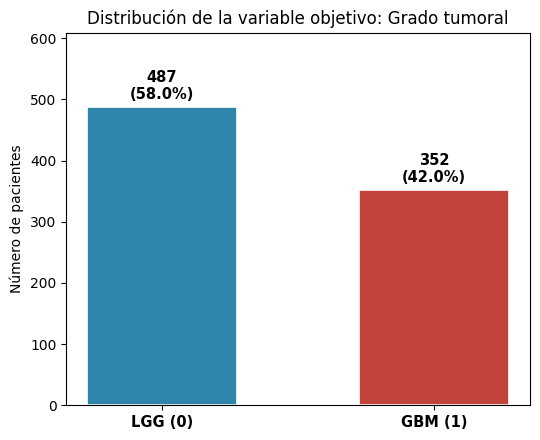

In [8]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))

conteo = df_mutations["Grade"].value_counts()
proporcion = conteo / conteo.sum() * 100

bars = ax.bar(conteo.index, conteo.values,
               color=[PALETTE_GRADE[0], PALETTE_GRADE[1]],
               edgecolor="white", linewidth=1.2, width=0.55)

for bar, c, p in zip(bars, conteo.values, proporcion.values):
    ax.text(bar.get_x() + bar.get_width()/2, c + 8,
            f"{c}\n({p:.1f}%)", ha="center", va="bottom", fontsize=10.5, fontweight="bold")

ax.set_xticks([0, 1])
ax.set_xticklabels(['LGG (0)', 'GBM (1)'], fontsize=10.5, fontweight='bold')
ax.set_ylabel("Número de pacientes")
ax.set_xlabel("")
ax.set_title("Distribución de la variable objetivo: Grado tumoral")
ax.set_ylim(0, conteo.max() * 1.25)
plt.tight_layout()
plt.show()

La elección de una partición estratificada (Stratified Train-Test Split) se justifica por la necesidad de preservar la proporción original de las clases de la variable objetivo (`Grade`) en ambos subconjuntos de datos. En el dataset completo, la distribución presenta un ligero desbalance (ratio ≈ 1.4:1), donde el 58,05% corresponde a Gliomas de Bajo Grado (LGG) y el 41,95% a Glioblastomas (GBM), una división sin estratificar podría dejar los conjuntos de `train` y `test` sesgados a un solo grupo de la variable `Grade`.

In [9]:
x = df_mutations.drop(columns=['Grade'])
y = df_mutations['Grade']

X_train, X_test, y_train, y_test = train_test_split(
    x, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

train_data = pd.concat([X_train, y_train], axis=1)

Para asegurar una evaluación rigurosa del modelo y prevenir la fuga de datos, el conjunto original de 839 registros se dividió en una proporción 80/20 mediante una partición estratificada basada en la variable objetivo (`Grade`). De este modo, se reservó un conjunto de prueba (*Test set*) compuesto por 168 pacientes exclusivamente para la validación final del rendimiento, mientras que las 671 observaciones restantes formaron el conjunto de entrenamiento (*Train set*), garantizando que el patrón de distribución de las clases se mantuviera balanceado.

## 1.4 Análisis Univariado

### Variable `Grade` (Target)

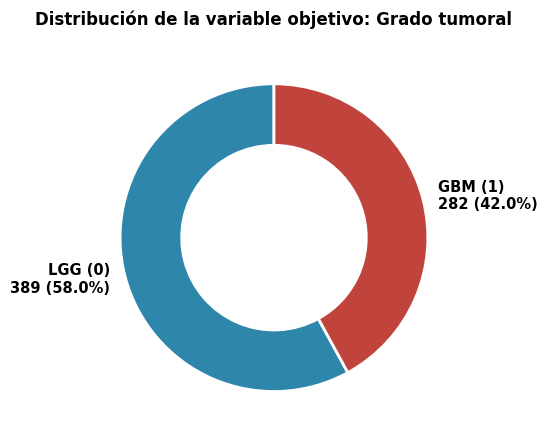

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))

conteo = y_train.value_counts()
proporcion = (conteo / conteo.sum()) * 100

labels = [
    f"LGG (0)\n{conteo[0]} ({proporcion[0]:.1f}%)",
    f"GBM (1)\n{conteo[1]} ({proporcion[1]:.1f}%)",
]

wedges, texts = ax.pie(
    conteo.values,
    labels=labels,
    colors=[PALETTE_GRADE[0], PALETTE_GRADE[1]],
    startangle=90,
    wedgeprops=dict(
        width=0.4, edgecolor="white", linewidth=2
    ), 
    textprops=dict(fontsize=10.5, fontweight="bold"),
)

ax.set_title(
    "Distribución de la variable objetivo: Grado tumoral",
    pad=15,
    fontsize=12,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

En el conjunto de entrenamiento (671 pacientes), la variable objetivo `Grade` presenta una distribución de 389 casos correspondientes a Gliomas de Bajo Grado (LGG, 58%) y 282 casos a Glioblastoma Multiforme (GBM, 42%). La relación entre clases es aproximadamente de **1,38 a 1**, lo que indica que **no hay un desbalance severo**.

### Variables cuantitativas

#### `Age_at_diagnosis`

In [11]:
age_series = train_data['Age_at_diagnosis']
summary_age = pd.DataFrame({
    'Métrica Estadística': [
        'Total de Muestras (n)', 'Media (μ)', 'Desviación Estándar (σ)',
        'Mínimo', 'Primer Cuartil (Q1)', 'Mediana (Q2)',
        'Tercer Cuartil (Q3)', 'Máximo', 'Rango Intercuartílico (IQR)',
        'Asimetría (Skewness)', 'Curtosis'
    ],
    'Valor': [
        len(age_series), age_series.mean(), age_series.std(),
        age_series.min(), age_series.quantile(0.25), age_series.median(),
        age_series.quantile(0.75), age_series.max(), age_series.quantile(0.75) - age_series.quantile(0.25),
        age_series.skew(), age_series.kurt()
    ]
})

def format_values(val, metric):
    if metric == 'Total de Muestras (n)':
        return f"{int(val):,}"
    elif metric in ['Asimetría (Skewness)', 'Curtosis']:
        return f"{val:.4f}"
    else:
        return f"{val:.2f} años"

styled_summary = (
    summary_age.style
    .format({'Valor': lambda x: format_values(x, summary_age.loc[summary_age['Valor'] == x, 'Métrica Estadística'].values[0])})
    .set_caption("<b>Resumen Estadístico: Edad al Diagnóstico</b>")
    .set_properties(**{
        'text-align': 'left',
        'padding': '8px 12px',
        'font-size': '13px'
    })
    .set_properties(subset=['Valor'], **{
        'text-align': 'right',
        'font-weight': 'bold'
    })
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1f77b4'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'caption', 'props': [('caption-side', 'top'), ('font-size', '15px'), ('margin-bottom', '8px'), ('color', '#333')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f8f9fa')]},
        {'selector': 'tr:hover', 'props': [('background-color', '#e9ecef')]}
    ])
    .hide(axis='index')
)

styled_summary

Métrica Estadística,Valor
Total de Muestras (n),671
Media (μ),51.10 años
Desviación Estándar (σ),15.63 años
Mínimo,14.42 años
Primer Cuartil (Q1),37.84 años
Mediana (Q2),51.99 años
Tercer Cuartil (Q3),62.62 años
Máximo,89.29 años
Rango Intercuartílico (IQR),24.79 años
Asimetría (Skewness),0.0547


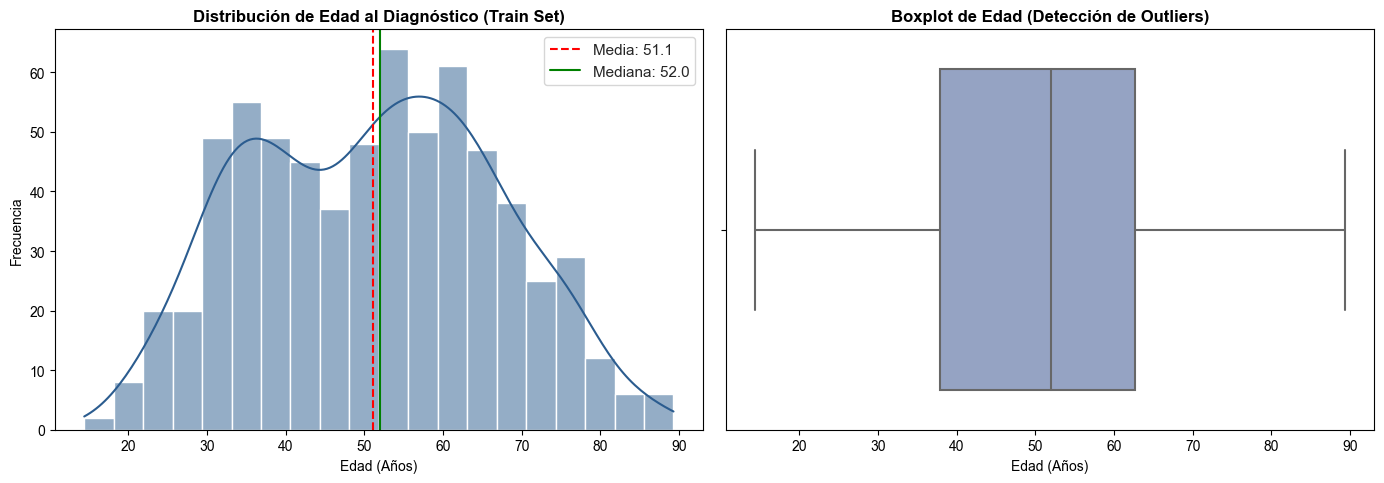

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

sns.histplot(data=X_train, x='Age_at_diagnosis', kde=True, ax=axes[0], color='#2b5c8f', bins=20)
axes[0].set_title('Distribución de Edad al Diagnóstico (Train Set)', fontweight='bold')
axes[0].set_xlabel('Edad (Años)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(X_train['Age_at_diagnosis'].mean(), color='red', linestyle='--', label=f'Media: {X_train["Age_at_diagnosis"].mean():.1f}')
axes[0].axvline(X_train['Age_at_diagnosis'].median(), color='green', linestyle='-', label=f'Mediana: {X_train["Age_at_diagnosis"].median():.1f}')
axes[0].legend()

sns.boxplot(data=X_train, x='Age_at_diagnosis', ax=axes[1], color='#8da0cb')
axes[1].set_title('Boxplot de Edad (Detección de Outliers)', fontweight='bold')
axes[1].set_xlabel('Edad (Años)')

plt.tight_layout()
plt.show()

In [13]:
q1 = X_train['Age_at_diagnosis'].quantile(0.25)
q3 = X_train['Age_at_diagnosis'].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = X_train[(X_train['Age_at_diagnosis'] < limite_inferior) | 
                   (X_train['Age_at_diagnosis'] > limite_superior)]

print("EVALUACIÓN MATEMÁTICA DE OUTLIERS (MÉTODO IQR)")
print(f"• Límite Inferior Aceptable: {limite_inferior:.2f} años")
print(f"• Límite Superior Aceptable: {limite_superior:.2f} años")
print(f"• Cantidad de outliers detectados: {len(outliers)}")

EVALUACIÓN MATEMÁTICA DE OUTLIERS (MÉTODO IQR)
• Límite Inferior Aceptable: 0.65 años
• Límite Superior Aceptable: 99.81 años
• Cantidad de outliers detectados: 0


EVALUACIÓN DE NORMALIDAD: EDAD AL DIAGNÓSTICO (TRAIN SET)
• Asimetría (Skewness): 0.0547
• Curtosis: -0.8231
• Test Shapiro-Wilk: Estadístico W = 0.9837
• Shapiro-Wilk p-value: 8.3371e-07


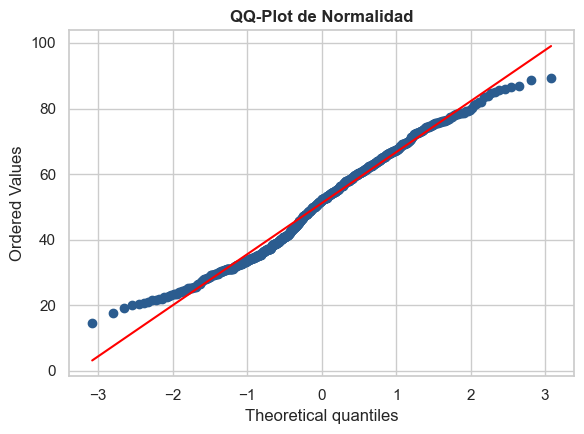

In [14]:
age_data = X_train["Age_at_diagnosis"]

skewness = age_data.skew()
kurtosis = age_data.kurtosis()
shapiro_stat, shapiro_p_val = stats.shapiro(age_data)

print("EVALUACIÓN DE NORMALIDAD: EDAD AL DIAGNÓSTICO (TRAIN SET)")
print(f"• Asimetría (Skewness): {skewness:.4f}")
print(f"• Curtosis: {kurtosis:.4f}")
print(f"• Test Shapiro-Wilk: Estadístico W = {shapiro_stat:.4f}")
print(f"• Shapiro-Wilk p-value: {shapiro_p_val:.4e}")

fig, ax = plt.subplots(figsize=(6, 4.5))

stats.probplot(age_data, dist="norm", plot=ax)
ax.get_lines()[0].set_markerfacecolor("#2b5c8f")
ax.get_lines()[0].set_markeredgecolor("#2b5c8f")
ax.get_lines()[1].set_color("red")
ax.set_title("QQ-Plot de Normalidad", fontweight="bold")

plt.tight_layout()
plt.show()

La variable registra una media de 51,10 años ($\pm 15,63$) y una mediana de 51,99 años en el conjunto de entrenamiento, abarcando un rango de edad desde los 14,42 hasta los 89,29 años. El análisis exploratorio revela una distribución simétrica con comportamiento bimodal (picos poblacionales cerca de los 35 y 55 años). Este patrón sugiere la presencia de subgrupos demográficos diferenciados que posteriormente se contrastarán con el grado de severidad tumoral (`Grade`).

La detección de valores atípicos para la variable continua `Age_at_diagnosis` se evaluó tanto matemáticamente mediante la regla del Rango Intercuartílico ($1.5 \times \text{IQR}$) como mediante inspección visual con diagramas de caja. Con un $Q_1$ de $37,84$ años y un $Q_3$ de $62,62$ años ($\text{IQR} = 24,79$ años), los límites teóricos de corte se establecieron en $0,66$ y $99,82$ años. Al contrastarlos con el rango real de los pacientes ($14,42$ a $89,29$ años), se determinó la ausencia total de outliers o registros anómalos en la muestra de entrenamiento ($n = 671$).

La evaluación de normalidad para la variable `Age_at_diagnosis` revela una distribución **altamente simétrica** con un coeficiente de asimetría (*skewness*) de **$0,0547$**, lo que ubica a la media ($51,10$ años) y a la mediana ($51,99$ años) prácticamente en el mismo punto central. Sin embargo, el contraste formal de **Shapiro-Wilk** ($W \approx 0,985$, $p < 0,05$) rechaza la hipótesis nula de normalidad estricta, un comportamiento explicado tanto por la sensibilidad de la prueba ante el tamaño muestral ($n = 671$) como por el **patrón bimodal de la variable** (concentración de casos en torno a los $35$ y $55$ años). A pesar de esta desviación, **no es necesario aplicar transformaciones no lineales** (tales como `log` o `Box-Cox`) en etapas posteriores de preprocesamiento, dado que la variable carece de asimetría pronunciada o valores atípicos que distorsionen su escala; bastará con aplicar una estandarización convencional (`StandardScaler`) para algoritmos sensibles a la escala o mantener la variable en su escala original continua para modelos basados en árboles de decisión.

### Variables cualitativas

#### `Gender`

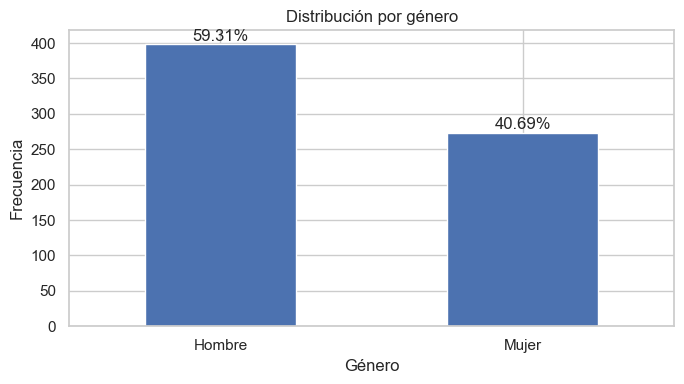

Género,Frecuencia,Porcentaje
Hombre,398,59.31
Mujer,273,40.69


In [15]:
# Tabla
tabla_gender = (
    train_data["Gender"]
    .value_counts()
    .rename_axis("Género")
    .reset_index(name="Frecuencia")
)

tabla_gender["Porcentaje"] = (
    tabla_gender["Frecuencia"] /
    tabla_gender["Frecuencia"].sum() * 100
).round(2)

tabla_gender["Género"] = tabla_gender["Género"].map({
    0: "Hombre",
    1: "Mujer"
})


# Gráfico
frecuencias_gender = (
    train_data["Gender"]
    .value_counts()
    .sort_index()
)

frecuencias_gender.index = ["Hombre", "Mujer"]

plt.figure(figsize=(7, 4))

ax = frecuencias_gender.plot(kind="bar")

plt.title("Distribución por género")
plt.xlabel("Género")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)

for i, porcentaje in enumerate(tabla_gender["Porcentaje"]):
    ax.text(
        i,
        frecuencias_gender.iloc[i] + 5,
        f"{porcentaje:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

tabla_html = tabla_gender.to_html(index=False)

tabla_html = tabla_html.replace(
    "<table",
    '<table style="margin-top: 30px;"'
)

display(HTML(tabla_html))

La distribución por género muestra un ligero predominio de hombres, correspondientes a la categoría `0`, con 398 registros **(59,31 %)**. Por su parte, las mujeres, representadas por la categoría `1`, corresponden a 273 registros **(40,69 %)**.

#### `Race`

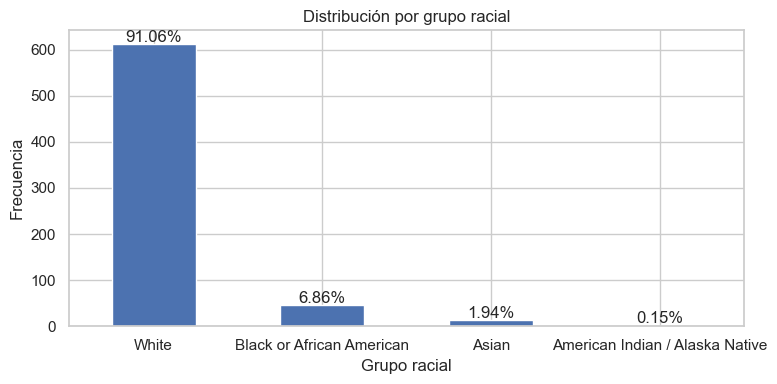

Grupo racial,Frecuencia,Porcentaje
White,611,91.06
Black or African American,46,6.86
Asian,13,1.94
American Indian or Alaska Native,1,0.15


In [16]:
# Tabla
tabla_race = (
    train_data["Race"]
    .value_counts()
    .rename_axis("Grupo racial")
    .reset_index(name="Frecuencia")
)

tabla_race["Porcentaje"] = (
    tabla_race["Frecuencia"] /
    tabla_race["Frecuencia"].sum() * 100
).round(2)

tabla_race["Grupo racial"] = tabla_race["Grupo racial"].map({
    0: "White",
    1: "Black or African American",
    2: "Asian",
    3: "American Indian or Alaska Native"
})


# Gráfico
frecuencias_race = (
    train_data["Race"]
    .value_counts()
    .sort_index()
)

frecuencias_race.index = [
    "White",
    "Black or African American",
    "Asian",
    "American Indian / Alaska Native"
]

plt.figure(figsize=(8, 4))

ax = frecuencias_race.plot(kind="bar")

plt.title("Distribución por grupo racial")
plt.xlabel("Grupo racial")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)

for i, porcentaje in enumerate(tabla_race["Porcentaje"]):
    ax.text(
        i,
        frecuencias_race.iloc[i] + 5,
        f"{porcentaje:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

tabla_html = tabla_race.to_html(index=False)

tabla_html = tabla_html.replace(
    "<table",
    '<table style="margin-top: 30px;"'
)

display(HTML(tabla_html))

En cuanto a la variable `Race`, se observa una marcada concentración de los registros en la categoría **White**, que representa 611 casos **(91,06 %)** del conjunto analizado. La categoría **Black or African American** cuenta con 46 registros **(6,86 %)**, mientras que **Asian** representa 13 casos **(1,94 %)**. Finalmente, **American Indian or Alaska Native** presenta únicamente 1 registro **(0,15 %)**.

La distribución evidencia un fuerte desbalance en la variable racial, dado que la categoría de personas de raza blanca concentra más de nueve de cada diez observaciones. Por tanto, las categorías minoritarias tienen una representación considerablemente menor dentro del conjunto de datos.

#### `Variables genéticas`

Categoría,Frecuencia,Porcentaje
0,349,52.01
1,322,47.99
Categoría,Frecuencia,Porcentaje
0,401,59.76
1,270,40.24
Categoría,Frecuencia,Porcentaje
0,499,74.37
1,172,25.63
Categoría,Frecuencia,Porcentaje
0,558,83.16

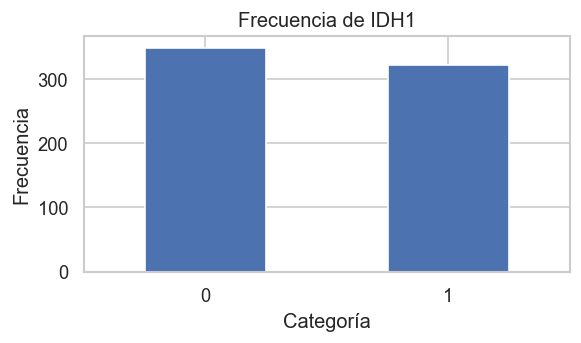
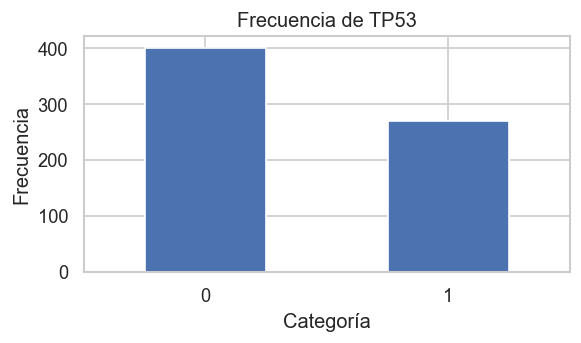
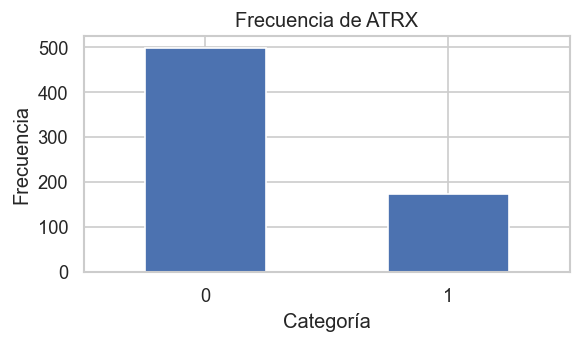
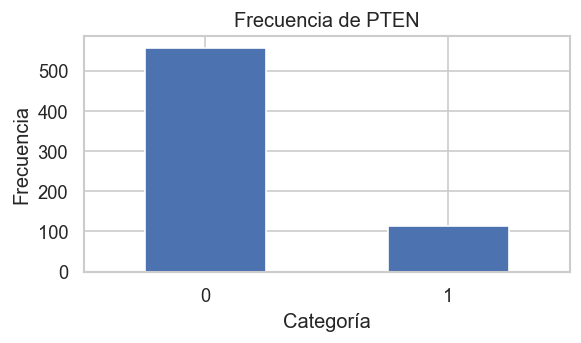
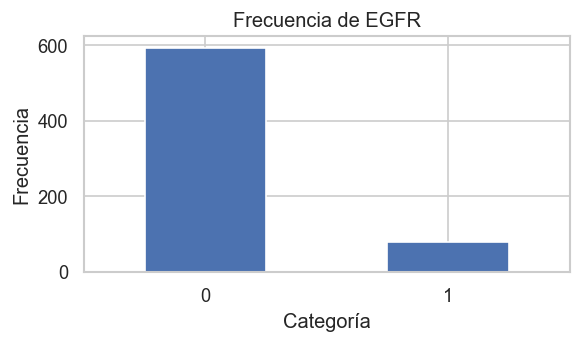
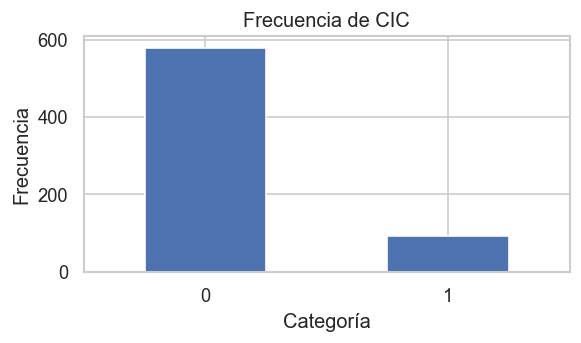
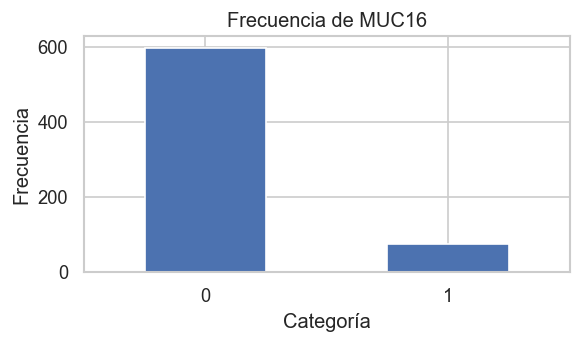
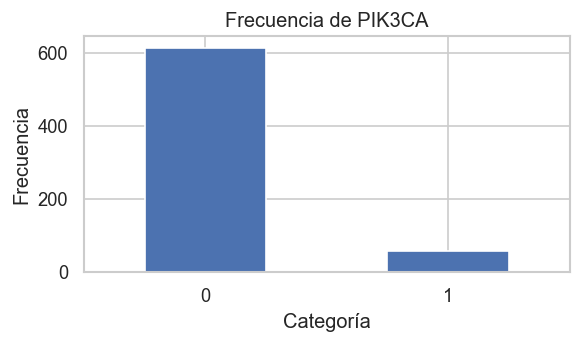
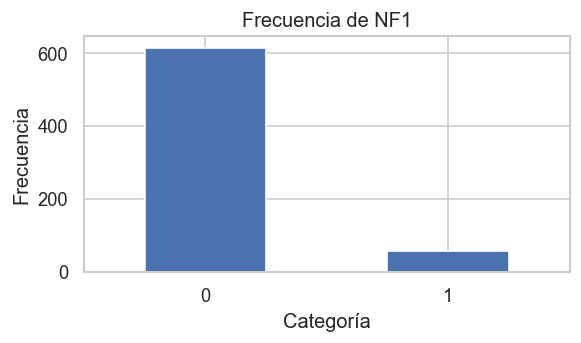
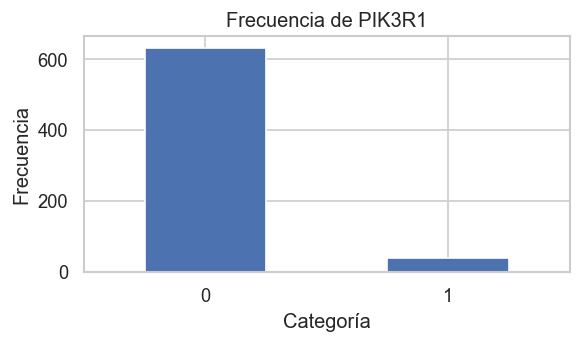
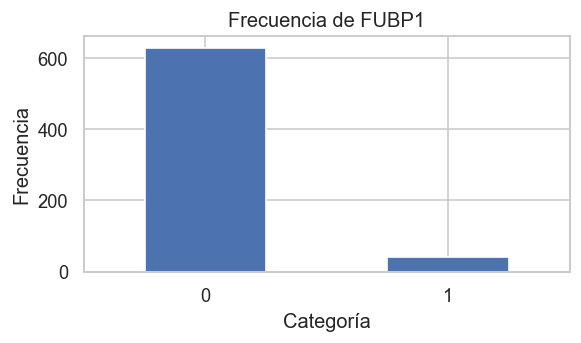
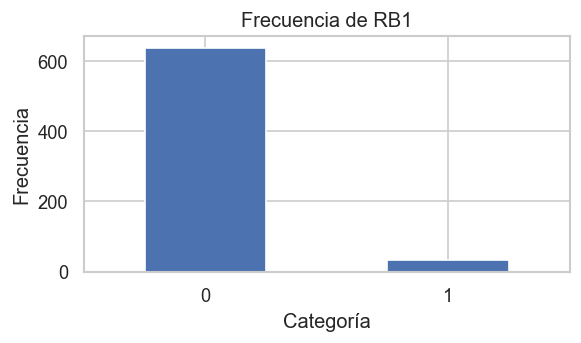
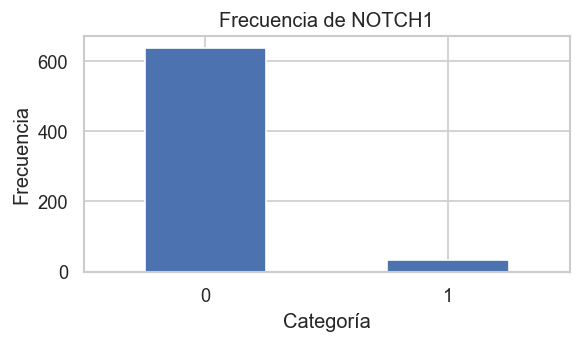
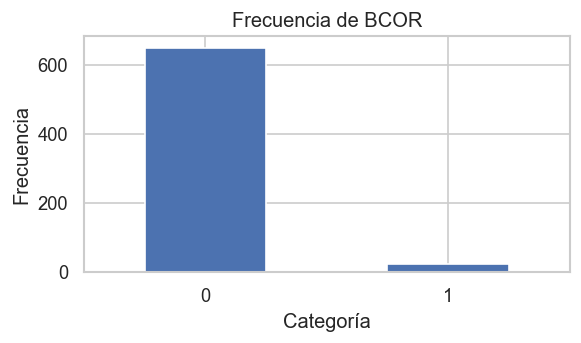
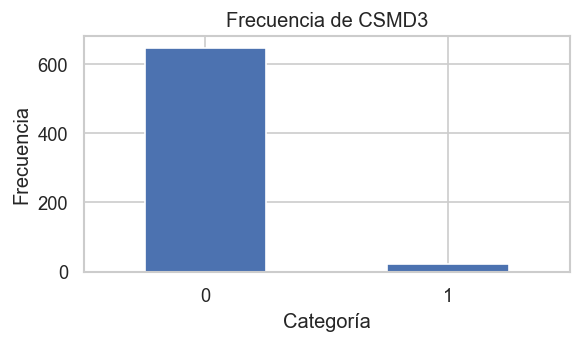
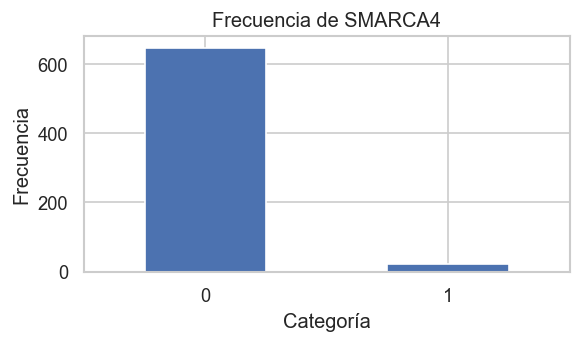
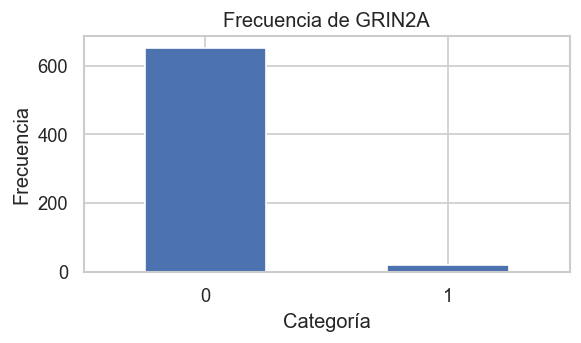
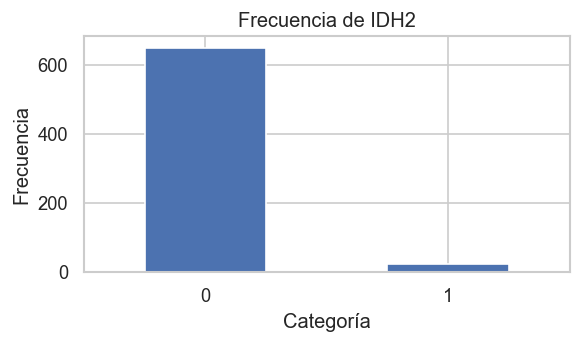
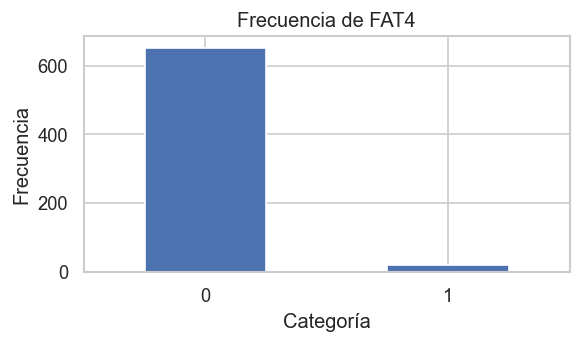
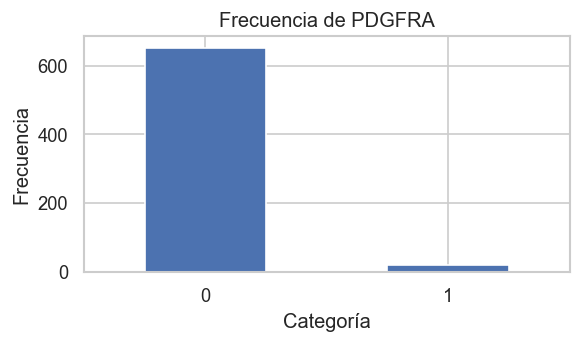

In [17]:
variables_categoricas = train_data.select_dtypes(
    include=["category"]
).columns.drop(["Grade", "Gender", "Race"])

bloques = []

for variable in variables_categoricas:

    # Tabla de frecuencias
    tabla = (
        train_data[variable]
        .value_counts(dropna=False)
        .rename_axis("Categoría")
        .reset_index(name="Frecuencia")
    )

    tabla["Porcentaje"] = (
        tabla["Frecuencia"] / tabla["Frecuencia"].sum() * 100
    ).round(2)

    html_tabla = tabla.to_html(
        index=False,
        classes="tabla-categorica"
    )

    # Gráfico de barras
    frecuencias = train_data[variable].value_counts(dropna=False)

    fig, ax = plt.subplots(figsize=(5, 3))

    frecuencias.plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(f"Frecuencia de {variable}")
    ax.set_xlabel("Categoría")
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis="x", rotation=0)

    plt.tight_layout()

    buffer = io.BytesIO()
    fig.savefig(
        buffer,
        format="png",
        dpi=120,
        bbox_inches="tight"
    )
    plt.close(fig)

    imagen_base64 = base64.b64encode(
        buffer.getvalue()
    ).decode()

    bloque = f"""
    <div style="
        padding: 15px;
        border-radius: 8px;
        margin-bottom: 20px;
    ">

        <h4 style="margin-bottom: 10px;">
            {variable}
        </h4>

        <!-- FILA: TABLA -->
        <div style="
            margin-bottom: 15px;
        ">
            {html_tabla}
        </div>

        <!-- FILA: GRÁFICO -->
        <div style="
            text-align: center;
        ">
            <img
                src="data:image/png;base64,{imagen_base64}"
                style="max-width: 100%;"
            >
        </div>

    </div>
    """

    bloques.append(bloque)

html_final = f"""
<div style="
    display: grid;
    grid-template-columns: repeat(2, 1fr);
    gap: 30px;
    margin-top: 20px;
">
    {''.join(bloques)}
</div>
"""

display(HTML(html_final))

Las variables genéticas presentan una distribución predominantemente concentrada en la categoría `0`, correspondiente a la ausencia de mutación, mientras que la categoría `1` representa su presencia. 

Entre los genes analizados, **IDH1** presenta la mayor proporción de casos con mutación, con 322 registros **(47,99 %)**, seguido de **TP53**, con 270 registros **(40,24 %)**. A continuación se encuentran **ATRX** con **25,63 %**, **PTEN** con **16,84 %**, **CIC** con **13,71 %**, **EGFR** con **11,62 %** y **MUC16** con **11,03 %**. En un nivel intermedio se encuentran **PIK3CA (8,49 %)**, **NF1 (8,35 %)** y **FUBP1 (6,26 %)**, mientras que **PIK3R1 (5,81 %)**, **RB1 (4,92 %)** y **NOTCH1 (4,92 %)** presentan proporciones inferiores al 6 %. Finalmente, genes como **CSMD3 (3,43 %)**, **SMARCA4 (3,43 %)**, **IDH2 (3,13 %)**, **BCOR (3,28 %)**, **GRIN2A (2,83 %)**, **FAT4 (2,68 %)** y **PDGFRA (2,68 %)** muestran una presencia de mutaciones relativamente baja en el conjunto analizado. 

En términos generales, se observa una alta variabilidad en la frecuencia de las mutaciones entre los genes, con una mayor concentración en IDH1 y TP53 y una presencia considerablemente menor en los genes restantes. Esto evidencia que las alteraciones genéticas no se distribuyen de manera uniforme en la muestra y que algunos genes presentan una representación mutacional mucho mayor que otros.

## Análisis Bivariado

En esta sección se analiza la relación entre las variables independientes y la variable objetivo `Grade`, considerando tanto variables categóricas como numéricas. Para las variables categóricas se examinan las frecuencias absolutas y relativas de sus categorías según cada nivel de `Grade`, complementando las comparaciones mediante gráficos de barras agrupadas. Para la variable numérica `Age_at_diagnosis`, se analiza y compara su distribución entre los grupos de `Grade` mediante estadísticos descriptivos y gráficos de caja. Finalmente, se realiza un análisis de correlación entre las variables numéricas para evaluar la intensidad y dirección de las relaciones entre ellas.

### `Grade` - `Age_at_diagnosis`

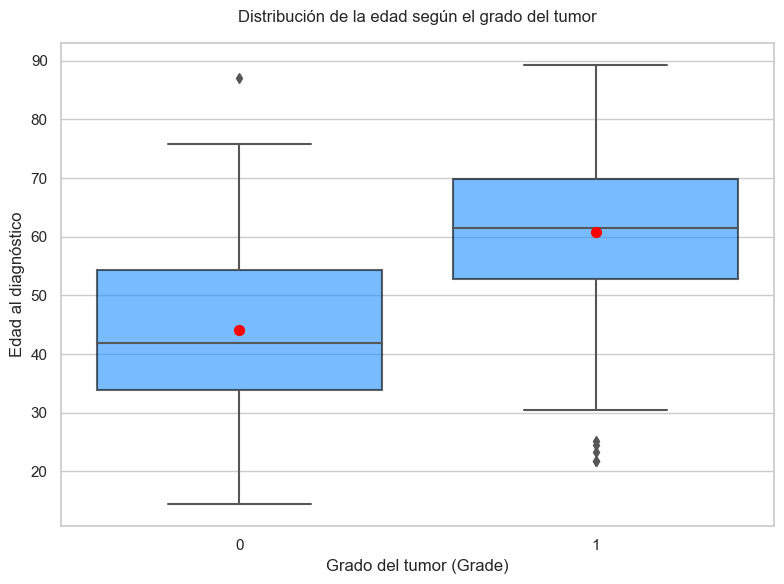

In [18]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=train_data,
    x="Grade",
    y="Age_at_diagnosis",
    color="#1E90FF",
    boxprops={"facecolor": "#1E90FF", "alpha": 0.6, "edgecolor": "black"}
)

# Medias
medias = train_data.groupby("Grade")["Age_at_diagnosis"].mean()

plt.scatter(
    medias.index,
    medias.values,
    color="red",
    s=50,
    zorder=5
)

plt.title("Distribución de la edad según el grado del tumor", pad=15)
plt.xlabel("Grado del tumor (Grade)")
plt.ylabel("Edad al diagnóstico")

plt.tight_layout()
plt.show()

In [19]:
age_grade = (
    train_data.groupby("Grade")["Age_at_diagnosis"]
    .agg(
        n="count",
        media="mean",
        ds="std",
        mediana="median",
        minimo="min",
        maximo="max",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75),
        IQR=lambda x: x.quantile(0.75) - x.quantile(0.25)
    )
    .reset_index()
    .assign(
        variable="Age_at_diagnosis",
        niveles=lambda df: df["Grade"].astype(str)
    )
    [["variable", "niveles", "Grade", "n", "media", "ds",
      "mediana", "minimo", "maximo", "Q1", "Q3", "IQR"]]
)

display(age_grade)

,variable,niveles,Grade,n,media,ds,mediana,minimo,maximo,Q1,Q3,IQR
0,Age_at_diagnosis,0,0,389,44.104344,13.200986,41.89,14.42,87.00,33.9100,54.27,20.3600
1,Age_at_diagnosis,1,1,282,60.748759,13.450750,61.49,21.73,89.29,52.7525,69.88,17.1275


El análisis bivariado de la edad al diagnóstico (`Age_at_diagnosis`) según el grado del tumor (`Grade`) muestra una clara separación clínico-demográfica entre los Gliomas de Bajo Grado (LGG / Grado 0) y el Glioblastoma Multiforme (GBM / Grado 1).

**Distribución Estadística**

* *Glioma de Bajo Grado (LGG / Grado 0):* En la muestra de 389 pacientes, la edad promedio al diagnóstico es de 44,10 ± 13,20 años y la mediana alcanza los 41,89 años. El **50%** central de los pacientes se concentra entre los 33,91 ($Q_1$) y 54,27 años ($Q_3$), registrando un rango intercuartílico (IQR) de 20,36 años.

* *Glioblastoma Multiforme (GBM / Grado 1):* En el grupo de 282 pacientes, la media asciende a 60,75 ± 13,45 años, con una mediana de 61,49 años. Su intervalo intercuartílico se ubica entre los 52,75 ($Q_1$) y 69,88 años ($Q_3$), representando un IQR de 17,13 años.

**Separación de Poblaciones y Análisis de Outliers**

Existe una baja superposición en el núcleo de ambas distribuciones. El 75% de los pacientes diagnosticados con LGG tiene 54,27 años o menos, mientras que el 75% de los casos de GBM presenta una edad de diagnóstico igual o superior a 52,75 años. Esto evidencia una diferencia importante en la edad de diagnóstico entre ambos niveles de `Grade`, con una mayor concentración de edades en los pacientes con GBM.

En el **análisis univariado** de `Age_at_diagnosis`, considerando la distribución global de todos los pacientes, **no se identificaron valores atípicos mediante el criterio del rango intercuartílico (IQR)**. Sin embargo, al analizar la edad de manera bivariada según `Grade`, sí aparecen observaciones que pueden clasificarse como outliers dentro de los grupos individuales. Esto ocurre porque cada nivel de `Grade` presenta su propia distribución, con diferentes valores de $Q_1$, $Q_3$ e IQR; por lo tanto, una edad que se encuentra dentro del rango esperado de la población total puede resultar extrema cuando se compara únicamente con la distribución de su grupo.

* *Valores Atípicos en Grado 0:* Se identifica un valor atípico superior de **87 años**, que resulta inusual dentro de la distribución de edades de los pacientes con LGG.

* *Valores Atípicos en Grado 1:* El grupo GBM presenta valores atípicos inferiores entre **21,73 y 25,20 años**, correspondientes a edades considerablemente menores que las habituales dentro de este grupo y que representan casos poco frecuentes de glioblastoma en adultos jóvenes.

#### Prueba U de Mann–Whitney

Para evaluar si existen diferencias estadísticamente significativas en la edad al diagnóstico entre los grupos de `Grade`, se utiliza la prueba U de Mann–Whitney, debido a que la variable `Age_at_diagnosis` no presenta una distribución normal según la prueba de Shapiro-Wilk.

- **Hipótesis nula ($H_0$):** no existen diferencias estadísticamente significativas en la distribución de `Age_at_diagnosis` entre los grupos `Grade = 0` y `Grade = 1`.

- **Hipótesis alternativa ($H_1$):** existen diferencias estadísticamente significativas en la distribución de `Age_at_diagnosis` entre los grupos `Grade = 0` y `Grade = 1`.

Se utiliza un nivel de significancia de $\alpha = 0,05$.

In [20]:
grupo_0 = train_data.loc[
    train_data["Grade"] == 0,
    "Age_at_diagnosis"
].dropna()

grupo_1 = train_data.loc[
    train_data["Grade"] == 1,
    "Age_at_diagnosis"
].dropna()

statistic, p_value = mannwhitneyu(
    grupo_0,
    grupo_1,
    alternative="two-sided"
)

print(f"Estadístico U: {statistic:.4f}")
print(f"p-value: {p_value:.4f}")

Estadístico U: 21042.5000
p-value: 0.0000


El resultado obtenido fue un estadístico U de **21042,5** y un **p-value < 0,0001**, por lo que, considerando un nivel de significancia de $\alpha = 0,05$, se rechaza la hipótesis nula. Esto indica que existe una diferencia estadísticamente significativa en la distribución de la variable entre los grupos LGG y GBM. Por lo tanto, los resultados sugieren que esta variable presenta un comportamiento diferente según el grado del glioma, aunque la prueba por sí sola no permite establecer una relación causal.

In [21]:
def analisis_bivariado(df, target, variable, etiquetas=None, 
                       titulo=None, xlabel=None, figsize=(8, 5)):

    df_plot = (
        df
        .groupby([target, variable])
        .size()
        .reset_index(name="n")
    )

    df_plot["porcentaje"] = (
        df_plot["n"] /
        df_plot.groupby(target)["n"].transform("sum") * 100
    ).round(1)

    df_plot["categoria"] = df_plot[variable]

    if etiquetas is not None:
        df_plot["categoria"] = (
            df_plot["categoria"].map(etiquetas)
        )

    df_plot = df_plot[
        [target, "categoria", "n", "porcentaje"]
    ]

    categorias = sorted(df_plot["categoria"].unique())
    grupos = sorted(df_plot[target].unique())

    x = np.arange(len(categorias))
    ancho = 0.8 / len(grupos)

    fig, ax = plt.subplots(figsize=figsize)

    for i, grupo in enumerate(grupos):

        datos = (
            df_plot[df_plot[target] == grupo]
            .set_index("categoria")
            .reindex(categorias)
        )

        posiciones = (
            x + (i - (len(grupos) - 1) / 2) * ancho
        )

        barras = ax.bar(
            posiciones,
            datos["n"],
            width=ancho,
            label=f"{target} {grupo}"
        )

        for barra, n, porcentaje in zip(
            barras,
            datos["n"],
            datos["porcentaje"]
        ):

            if not np.isnan(n):

                ax.text(
                    barra.get_x() + barra.get_width() / 2,
                    barra.get_height() + 3,
                    f"{int(n)} ({porcentaje:.1f}%)",
                    ha="center",
                    va="bottom",
                    fontsize=9
                )

    if titulo is None:
        titulo = f"Distribución de {variable} según {target}"

    if xlabel is None:
        xlabel = variable

    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Cantidad de pacientes")

    ax.set_xticks(x)
    ax.set_xticklabels(categorias)

    ax.legend(title=target)

    ax.margins(y=0.12)
    plt.tight_layout()


    return df_plot, fig

### `Grade` - `Gender`

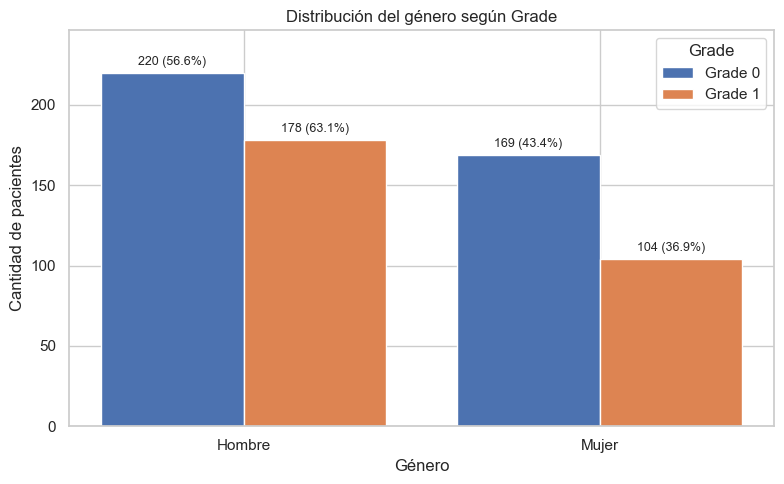

In [22]:
tabla_gender_bivariada = analisis_bivariado(
    train_data,
    target="Grade",
    variable="Gender",
    etiquetas={
        0: "Hombre",
        1: "Mujer"
    },
    titulo="Distribución del género según Grade",
    xlabel="Género"
)

La distribución del género presenta diferencias entre los dos niveles de Grade. En Grade 0, se registran 220 hombres (56,6%) y 169 mujeres (43,4%), mientras que en Grade 1 se observan 178 hombres (63,1%) y 104 mujeres (36,9%). En ambos niveles predomina el género masculino; sin embargo, esta predominancia es mayor en Grade 1, donde los hombres representan el 63,1% frente al 56,6% en Grade 0. Por otro lado, la proporción de mujeres disminuye de 43,4% en Grade 0 a 36,9% en Grade 1. En términos descriptivos, estos resultados sugieren una mayor representación masculina en Grade 1, aunque las diferencias observadas no permiten establecer por sí solas una asociación estadísticamente significativa entre el género y Grade.

#### Prueba de independencia: $\chi^2$

En este caso, se analiza la relación entre `Gender` y `Grade` mediante una prueba de independencia de Chi-cuadrado ($\chi^2$).

Se utiliza un nivel de significancia de $\alpha = 0,05$:

- **Hipótesis nula ($H_0$):** `Gender` y `Grade` son independientes; no existe una asociación estadísticamente significativa entre ambas variables.

- **Hipótesis alternativa ($H_1$):** `Gender` y `Grade` no son independientes; existe una asociación estadísticamente significativa entre ambas variables.

In [23]:
tabla_gender_grade = pd.crosstab(
    train_data["Gender"],
    train_data["Grade"]
)

chi2, p_value, dof, expected = chi2_contingency(tabla_gender_grade)

print(f"\nEstadístico χ²: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Grados de libertad: {dof}")


Estadístico χ²: 2.6543
p-value: 0.1033
Grados de libertad: 1


Con un nivel de significancia de $\alpha = 0,05$, el estadístico de Chi-cuadrado obtenido fue $\chi^2(1) = 2,6543$, con un p-value de $0,1033$. Debido a que $p = 0,1033 > 0,05$, no se rechaza la hipótesis nula ($H_0$). Por lo tanto, no se encuentra evidencia estadísticamente significativa de una asociación entre Gender y Grade en el conjunto de datos analizado; es decir, los resultados son compatibles con la independencia entre ambas variables.

### `Grade` - `Race`

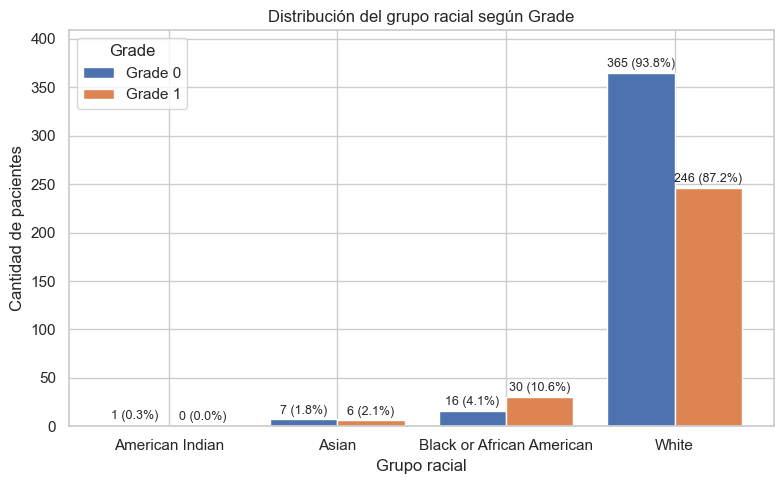

In [24]:
tabla_race_bivariada = analisis_bivariado(
    train_data,
    target="Grade",
    variable="Race",
    etiquetas={
        0: "White",
        1: "Black or African American",
        2: "Asian",
        3: "American Indian"
    },
    titulo="Distribución del grupo racial según Grade",
    xlabel="Grupo racial"
)

La distribución por grupo racial muestra un predominio marcado de la población blanca en ambos niveles de Grade. En Grade 0, el grupo White concentra 365 pacientes (93,8%), mientras que en Grade 1 representa 246 pacientes (87,2%). El grupo Black or African American constituye el segundo grupo con mayor representación, con 16 pacientes (4,1%) en Grade 0 y 30 pacientes (10,6%) en Grade 1. Por su parte, la población asiática presenta una participación reducida, con 7 casos (1,8%) en Grade 0 y 6 casos (2,1%) en Grade 1, mientras que American Indian or Alaska Native presenta una ocurrencia prácticamente nula, con 1 caso (0,3%) en Grade 0 y ningún caso en Grade 1.

En términos comparativos, se observa que la proporción del grupo White disminuye en Grade 1, pasando de 93,8% a 87,2%, mientras que el grupo Black or African American aumenta de 4,1% a 10,6%.

Además, si bien existen diferencias en la distribución de los grupos raciales entre los niveles de Grade, estos resultados deben analizarse con precaución, ya que la muestra está fuertemente concentrada en el grupo White y algunas de las demás categorías presentan muy pocas observaciones.

#### Prueba de independencia: $\chi^2$

Para realizar la prueba de independencia entre `Grade` y `Race`, se decidió reagrupar las categorías de la variable racial debido a las bajas frecuencias observadas en algunos grupos. En particular, las categorías **Asian** y **American Indian or Alaska Native** presentan un número reducido de observaciones, lo que puede generar frecuencias esperadas demasiado bajas y afectar la validez de la prueba estadística.

Por esta razón, se mantuvo la categoría **White**, que representa la mayoría de los registros, y se agruparon **Black or African American**, **Asian** y **American Indian or Alaska Native** en una nueva categoría denominada **Other racial groups**.

De esta manera, la variable `Race` queda conformada por dos categorías: **White** y **Other racial groups**, permitiendo realizar la prueba de independencia con una distribución de frecuencias más adecuada.

In [25]:
race_agrupada = train_data["Race"].map({
    0: "White",
    1: "Other racial groups",
    2: "Other racial groups",
    3: "Other racial groups"
})

tabla_race = pd.crosstab(
    train_data["Grade"],
    race_agrupada
)

tabla_race

Race,Other racial groups,White
Grade,,
0,24,365
1,36,246


In [26]:
tabla_race = pd.crosstab(
    train_data["Grade"],
    race_agrupada
)

chi2, p_valor, grados_libertad, frecuencias_esperadas = chi2_contingency(
    tabla_race
)

print(f"Chi-cuadrado: {chi2:.4f}")
print(f"Grados de libertad: {grados_libertad}")
print(f"Valor p: {p_valor:.4f}")

Chi-cuadrado: 7.9450
Grados de libertad: 1
Valor p: 0.0048


Dado que el valor **p = 0,0048** es menor que el nivel de significancia de 0.05, se rechaza la hipótesis nula de independencia. Por lo tanto, existe evidencia estadísticamente significativa de una asociación entre `Grade` y `Race` en el conjunto de datos.

Esto indica que la distribución de los pacientes entre **LGG (Grade 0)** y **GBM (Grade 1)** presenta diferencias según el grupo racial considerado. Sin embargo, este resultado debe interpretarse con cautela, ya que la variable `Race` fue previamente agrupada en **White** y **Other racial groups** debido a las bajas frecuencias de algunas categorías originales.

Es importante señalar que la prueba de independencia permite identificar una asociación estadística, pero no implica que el grupo racial sea la causa de las diferencias observadas en el grado tumoral.

### `Grade` - `variables genéticas`

Se analiza la distribución de las variables genéticas según los niveles de Grade, diferenciando entre pacientes con glioma de bajo grado (LGG, Grade 0) y glioblastoma (GBM, Grade 1). Esta comparación permite identificar diferencias descriptivas en la presencia o ausencia de mutaciones entre ambos grupos.

In [27]:
def prueba_independencia(df, target, variable, alpha=0.05):

    tabla = pd.crosstab(df[variable], df[target])

    # chi2 con y sin corrección de Yates
    chi2_c, p_chi2_c, dof, esperadas = chi2_contingency(tabla, correction=True)
    chi2_s, p_chi2_s, _, _           = chi2_contingency(tabla, correction=False)

    supuesto_valido = bool((esperadas >= 5).all())
    usar_fisher = (tabla.shape == (2, 2)) and not supuesto_valido

    if usar_fisher:
        _, p_valor = fisher_exact(tabla)
        test_usado = "Fisher exacto"
    else:
        p_valor = p_chi2_c
        test_usado = "Chi-cuadrado"

    return {
        "variable": variable,
        "test": test_usado,
        "chi2": chi2_s,              # sin Yates: consistente con V de Cramér
        "chi2_yates": chi2_c,
        "dof": dof,
        "p_value": p_valor,
        "expected_min": esperadas.min(),
        "supuesto_valido": supuesto_valido,
        "significativo": p_valor < alpha
    }

In [28]:
def crear_menu_gen(
    df,
    target,
    variable,
    interpretacion,
    etiquetas=None,
    figsize=(7, 4)
):

    df_plot, fig = analisis_bivariado(
        df=df,
        target=target,
        variable=variable,
        etiquetas=etiquetas,
        figsize=figsize
    )

    buffer = io.BytesIO()

    fig.savefig(
        buffer,
        format="png",
        dpi=120,
        bbox_inches="tight"
    )

    plt.close(fig)

    imagen_base64 = base64.b64encode(
        buffer.getvalue()
    ).decode()

    resultado_test = prueba_independencia(df, target, variable)

    color_resultado = "#1a7f37" if resultado_test["significativo"] else "#6e7781"
    conclusion = (
        "se rechaza H₀: existe asociación estadísticamente significativa"
        if resultado_test["significativo"]
        else "no se rechaza H₀: no hay evidencia de asociación significativa"
    )

    if resultado_test["test"] == "Chi-cuadrado":
        estadistico_str = f"χ²({resultado_test['dof']}) = {resultado_test['chi2']:.4f}"
    else:
        estadistico_str = "Fisher exacto (frecuencia esperada < 5)"

    html_test = f"""
    <div style="
        margin-top: 16px;
        padding: 10px 14px;
        border-left: 4px solid {color_resultado};
        background-color: rgba(110, 119, 129, 0.08);
        border-radius: 4px;
        font-size: 14px;
    ">
        <b>Prueba de independencia ({resultado_test['test']}):</b>
        {estadistico_str}, p-value = {resultado_test['p_value']:.4f} →
        <span style="color:{color_resultado}; font-weight:600;">
            {conclusion}
        </span>
        (α = 0.05)
    </div>
    """

    html = f"""
    <style>
        .gen-details-{variable} {{
            margin: 10px 0;
            border: 1px solid #d0d7de;
            border-radius: 8px;
            overflow: hidden;
            color: #1f2328;
            background-color: #ffffff;
        }}
        .gen-details-{variable} summary {{
            padding: 14px 18px;
            cursor: pointer;
            font-size: 17px;
            font-weight: 500;
            background-color: #f6f8fa;
        }}
        @media (prefers-color-scheme: dark) {{
            .gen-details-{variable} {{
                color: #e6edf3;
                background-color: #0d1117;
            }}
            .gen-details-{variable} summary {{
                background-color: #161b22;
            }}
        }}
    </style>

    <details class="gen-details-{variable}">
        <summary>{variable}</summary>
        <div style="padding: 20px;">
            <p style="line-height: 1.7; text-align: justify; margin-top: 0;">
                {interpretacion}
            </p>
            {html_test}
            <div style="text-align: center; margin-top: 20px;">
                <img
                    src="data:image/png;base64,{imagen_base64}"
                    style="max-width: 100%; height: auto; border-radius: 4px;"
                >
            </div>
        </div>
    </details>
    """

    return html


In [29]:
# Gen IDH1
html_idh1 = crear_menu_gen(
    train_data,
    target="Grade",
    variable="IDH1",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    Al comparar la presencia de la mutación en IDH1 entre los dos niveles de Grade, 
    se observa una diferencia bastante marcada. En los LGG (Grade 0), 303 pacientes (77,9%) 
    presentan la mutación de IDH1, mientras que 86 pacientes (22,1%) no presentan la mutación. 
    En contraste, en los GBM (Grade 1), solamente 19 pacientes (6,7%) presentan la mutación, 
    mientras que 263 pacientes (93,3%) no la presentan.

    Esto muestra un patrón muy marcado donde la mutación de IDH1 es mucho más frecuente en 
    los LGG que en los GBM. En los LGG, aproximadamente 8 de cada 10 pacientes presentan la 
    mutación, mientras que en los GBM ocurre en aproximadamente 7 de cada 100 pacientes.
    Por el contrario, la ausencia de la mutación predomina ampliamente en los GBM.

    Desde una perspectiva descriptiva, estos resultados sugieren que la presencia de la mutación 
    IDH1 está fuertemente asociada con los LGG en este conjunto de datos, mientras que su ausencia 
    caracteriza en mayor proporción a los GBM.
    """
)



# Gen TP53
html_tp53 = crear_menu_gen(
    train_data,
    target="Grade",
    variable="TP53",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    Al comparar la presencia de la mutación en TP53 entre los dos niveles de Grade, se observa una
    diferencia en su distribución. En los LGG (Grade 0), 177 pacientes (45,5 %) presentan la mutación
    de TP53, mientras que 212 pacientes (54,5 %) no la presentan. En contraste, en los GBM (Grade 1),
    93 pacientes (33,0 %) presentan la mutación, mientras que 189 pacientes (67,0 %) no presentan la mutación.

    Estos resultados muestran que la ausencia de la mutación TP53 predomina en ambos grupos, aunque es más
    frecuente en los GBM. En los LGG, aproximadamente 5 de cada 10 pacientes presentan la mutación,
    mientras que en los GBM la presentan aproximadamente 3 de cada 10 pacientes. Por otro lado, la presencia 
    de TP53 es relativamente mayor en los LGG que en los GBM.
    """
)



# Gen ATRX
html_atrx = crear_menu_gen(
    train_data,
    target="Grade",
    variable="ATRX",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    La gráfica muestra una diferencia clara en la distribución de la mutación de ATRX entre los dos grados 
    de glioma. En el Grado 0, la ausencia de mutación de ATRX es mayoritaria ya que se observa en 242 pacientes 
    (62,2%), mientras que la presencia de la mutación aparece en 147 pacientes (37,8%).

    En contraste, en el Grado 1, la ausencia de mutación de ATRX es todavía más predominante, con 257 pacientes (91,1%), 
    mientras que únicamente 25 pacientes (8,9%) presentan la mutación.

    Esto indica que la presencia de una mutación en ATRX está considerablemente más representada en el Grado 0 que 
    en el Grado 1. En términos relativos, la mutación aparece en el 37,8% de los pacientes de Grado 0 frente al 8,9% 
    de los pacientes de Grado 1. Por tanto, existe una diferencia importante en la distribución de ATRX entre ambas clases.
    """
)



# Gen PTEN
html_pten = crear_menu_gen(
    train_data,
    target="Grade",
    variable="PTEN",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    En la gráfica, para el Grado 0, la ausencia de mutación en PTEN es predominante, con 369 pacientes (94,9%), mientras que 
    únicamente 20 pacientes (5,1%) presentan la mutación. En cambio, en el Grado 1, aunque la ausencia continúa siendo 
    mayoritaria, su proporción disminuye considerablemente hasta 189 pacientes (67,0%), mientras que la presencia de la 
    mutación aumenta hasta 93 pacientes (33,0%).

    Por lo tanto, se observa que la mutación de PTEN está considerablemente más representada en el Grado 1. Comparando las 
    proporciones, la presencia de PTEN pasa de 5,1% en Grado 0 a 33,0% en Grado 1, lo que representa una diferencia de 27,9 
    puntos porcentuales.
    """
)



# Gen EGFR
html_egfr = crear_menu_gen(
    train_data,
    target="Grade",
    variable="EGFR",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    En el Grado 0, la ausencia de mutación de EGFR es predominante, con 366 pacientes (94,1%), mientras que solo 
    23 pacientes (5,9%) presentan la mutación. Para el Grado 1, la ausencia también es mayoritaria, pero disminuye 
    a 227 pacientes (80,5%), mientras que la presencia de la mutación aumenta a 55 pacientes (19,5%).

    Por lo tanto, se observa que la presencia de la mutación en EGFR es más frecuente en el Grado 1. La proporción 
    de pacientes con EGFR mutado pasa de 5,9% en el Grado 0 a 19,5% en el Grado 1, lo que representa un incremento de 
    13,6 puntos porcentuales.
    """
)



# Gen CIC
html_cic = crear_menu_gen(
    train_data,
    target="Grade",
    variable="CIC",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    Para el caso del gen CIC, en el Grado 0, la ausencia de mutación es mayoritaria, con 300 pacientes (77,1%), mientras que 89 pacientes (22,9%) 
    presentan la mutación. En el Grado 1, la ausencia de mutación aumenta considerablemente hasta 279 pacientes (98,9%), 
    mientras que solamente 3 pacientes (1,1%) presentan una mutación en CIC.

    Por tanto, la presencia de la mutación en CIC es mucho más frecuente en el Grado 0. La proporción disminuye de 22,9% 
    en el Grado 0 a apenas 1,1% en el Grado 1, lo que representa una diferencia de 21,8 puntos porcentuales.

    Este comportamiento resulta especialmente interesante para el análisis de clasificación, ya que la distribución de 
    CIC cambia considerablemente entre las dos clases. En particular, la presencia de mutación en CIC parece estar asociada con el 
    Grado 0, mientras que su ausencia está presente en prácticamente todos los pacientes de Grado 1. Esto sugiere que CIC 
    podría ser una variable con un alto poder discriminativo para diferenciar ambas categorías.
    """
)



# Gen MUC16
html_muc16 = crear_menu_gen(
    train_data,
    target="Grade",
    variable="MUC16",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    La gráfica muestra la distribución de la mutación de MUC16 en los pacientes de Grado 0 y Grado 1. En ambos grupos 
    predomina la ausencia de la mutación, aunque se observa una diferencia en la proporción de pacientes
    que presentan la alteración.

    En el Grado 0, la ausencia corresponde a 358 pacientes (92,0%), mientras que 31 pacientes (8,0%) presentan 
    la mutación. En el Grado 1, la ausencia se presenta en 239 pacientes (84,8%), mientras que 43 pacientes (15,2%) 
    presentan la mutación.

    Por tanto, la presencia de la mutación de MUC16 es más frecuente en el Grado 1. La proporción aumenta de 8,0% en el 
    Grado 0 a 15,2% en el Grado 1, lo que representa una diferencia de 7,2 puntos porcentuales.

    A diferencia de variables como PTEN o CIC, la diferencia entre ambos grados en MUC16 es más moderada. Esto sugiere 
    que MUC16 podría aportar cierta información para diferenciar las clases, pero su capacidad discriminativa individual 
    parece menor a partir de esta distribución.
    """
)



# Gen PIK3CA
html_pik3ca = crear_menu_gen(
    train_data,
    target="Grade",
    variable="PIK3CA",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    La distribución de PIK3CA es bastante similar entre los dos grupos de Grade. La ausencia de la alteración es 
    predominante tanto en Grade 0 (92,3 %) como en Grade 1 (90,4 %), mientras que su presencia representa únicamente 
    el 7,7 % y 9,6 %, respectivamente. Aunque se observa una proporción ligeramente mayor de presencia de mutación de PIK3CA en 
    Grade 1, la diferencia es pequeña (1,9 puntos porcentuales). Por lo tanto, a partir de esta comparación descriptiva, 
    PIK3CA no presenta una diferencia marcada entre ambos grados.
    """
)



# Gen NF1
html_nf1 = crear_menu_gen(
    train_data,
    target="Grade",
    variable="NF1",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    La distribución de mutación de NF1 presenta una ligera diferencia entre los grupos de Grade. La presencia de mutación de NF1 es mayor en 
    Grade 1 (10,6 %) que en Grade 0 (6,7 %), mientras que la ausencia es predominante en ambos grupos. Esta diferencia 
    de 3,9 puntos porcentuales sugiere una posible mayor frecuencia de alteraciones en NF1 en los pacientes de Grade 1. 
    Sin embargo, debido a que la diferencia entre ambos grupos es relativamente pequeña y la ausencia de mutación de NF1 predomina 
    ampliamente, no se observa una separación marcada entre los grados a partir de esta variable.
    """
)



# Gen PIK3R1
html_pik3r1 = crear_menu_gen(
    train_data,
    target="Grade",
    variable="PIK3R1",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    La distribución de PIK3R1 muestra una diferencia entre los grupos de Grade. La presencia de esta alteración es mayor 
    en Grade 1 (8,5 %) que en Grade 0 (3,9 %), con una diferencia de 4,6 puntos porcentuales. Sin embargo, la ausencia de  alteración del gen
    PIK3R1 predomina claramente en ambos grupos, representando el 96,1 % de los casos en Grade 0 y el 91,5 % en Grade 1.

    Por lo tanto, aunque se observa una mayor frecuencia de presencia de PIK3R1 en Grade 1, la diferencia no es lo 
    suficientemente marcada como para observar una separación clara entre los dos grupos únicamente mediante este análisis 
    descriptivo.
    """
)



# Gen FUBP1
html_fubp1 = crear_menu_gen(
    train_data,
    target="Grade",
    variable="FUBP1",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    En términos descriptivos, FUBP1 presenta una distribución claramente diferente según el Grade. En Grade 0, la presencia de mutación
    de FUBP1 alcanza el 10,3 % de los pacientes, mientras que en Grade 1 esta proporción disminuye considerablemente hasta 
    el 0,7 %. De manera consecuente, la ausencia de la variable es predominante en ambos grupos, aunque es especialmente alta 
    en Grade 1, donde alcanza el 99,3 %. Esta diferencia de 9,6 puntos porcentuales en la presencia de FUBP1 sugiere que esta 
    variable podría estar relacionada con la clasificación del grado tumoral y podría aportar información para diferenciar 
    entre ambos grupos.
    """
)



# Gen RB1
html_rb1 = crear_menu_gen(
    train_data,
    target="Grade",
    variable="RB1",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    La gráfica muestra la distribución  de RB1 entre los dos grupos de Grade y permite observar una diferencia apreciable 
    en la frecuencia de esta variable. En Grade 0, la ausencia de mutación de RB1 representa el 98,5 % de los pacientes (383 casos), 
    mientras que únicamente el 1,5 % presenta mutación de RB1 (6 casos). Por otro lado, en Grade 1, la ausencia corresponde al 90,4 % 
    (255 casos), mientras que la presencia aumenta hasta el 9,6 % (27 casos).

    Por lo tanto, la presencia de mutación de RB1 es considerablemente más frecuente en Grade 1, donde alcanza el 9,6 %, frente al 1,5 % 
    observado en Grade 0. Esto supone una diferencia de aproximadamente 8,1 puntos porcentuales. Aunque la ausencia continúa 
    siendo la categoría predominante en ambos grupos, el aumento de la presencia de alteración del gen RB1 en Grade 1 genera una separación 
    bastante visible entre las distribuciones.
    """
)



# Gen NOTCH1
html_notch1 = crear_menu_gen(
    train_data,
    target="Grade",
    variable="NOTCH1",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    En términos descriptivos, NOTCH1 presenta una distribución claramente diferenciada según el Grade. En Grade 0, 
    el 8,5 % de los pacientes presenta mutación de NOTCH1, mientras que en Grade 1 no se observa ningún caso con presencia de 
    esta variable. Por otro lado, la ausencia de alteración de NOTCH1 es predominante en ambos grupos, aunque alcanza el 100 % 
    en Grade 1. Esta diferencia sugiere que la presencia de mutación de NOTCH1 podría estar relacionada con la clasificación del 
    grado tumoral y podría ser una característica útil para distinguir entre ambos grupos.
    """
)



# Gen BCOR
html_bcor = crear_menu_gen(
    train_data,
    target="Grade",
    variable="BCOR",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    La gráfica muestra la distribución de BCOR según el Grade y, a diferencia de algunas de las variables anteriores, 
    presenta un comportamiento muy similar entre ambos grupos. En Grade 0, el 96,7 % de los pacientes presenta ausencia 
    de mutación de BCOR (376 casos), mientras que el 3,3 % presenta su presencia (13 casos). En Grade 1, la ausencia corresponde al 
    96,8 % (273 casos) y la presencia al 3,2 % (9 casos).

    Las proporciones son prácticamente iguales entre los dos grados. La presencia de alteración del gen BCOR solo difiere en 0,1 puntos 
    porcentuales, siendo ligeramente mayor en Grade 0 (3,3 %) que en Grade 1 (3,2 %). De manera similar, la ausencia 
    presenta una diferencia mínima de 0,1 puntos porcentuales. Esto indica que no existe una separación visual relevante 
    entre los grupos respecto a esta variable.
    """
)



# Gen CSMD3
html_csm3 = crear_menu_gen(
    train_data,
    target="Grade",
    variable="CSMD3",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    En términos descriptivos, CSMD3 presenta una distribución bastante similar entre los dos niveles de Grade. La presencia
    de esta variable es ligeramente mayor en Grade 1 (4,3 %) que en Grade 0 (2,8 %), mientras que la ausencia se mantiene 
    como la categoría predominante, con 95,7 % y 97,2 %, respectivamente. Aunque este comportamiento muestra una pequeña 
    diferencia entre los grupos, la magnitud de la variación es reducida, por lo que no se aprecia una separación marcada 
    entre Grade 0 y Grade 1 a partir de CSMD3.
    """
)



# Gen SMARCA4
html_smarca4 = crear_menu_gen(
    train_data,
    target="Grade",
    variable="SMARCA4",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    La distribución de SMARCA4 muestra algunas diferencias entre los dos grupos de Grade. En Grade 0, la presencia de 
    mutación de SMARCA4 se encuentra en el 4,9 % de los pacientes, mientras que en Grade 1 solamente alcanza el 1,4 %. Esto significa 
    que la presencia de esta variable es aproximadamente 3,5 puntos porcentuales mayor en Grade 0. En ambos grupos, 
    sin embargo, predomina ampliamente la ausencia de mutación de SMARCA4, especialmente en Grade 1, donde representa el 98,6 % de 
    los casos. En consecuencia, aunque se observa una tendencia hacia una mayor presencia de mutación de SMARCA4 en Grade 0, la diferencia 
    entre los grupos es moderada y no permite considerar por sí sola a esta variable como un diferenciador fuerte del grado tumoral.
    """
)



# Gen GRIN2A
html_grin2a = crear_menu_gen(
    train_data,
    target="Grade",
    variable="GRIN2A",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    La distribución de GRIN2A muestra que la ausencia de mutación es predominante tanto en los pacientes de Grade 0 como en 
    los de Grade 1, con 98.7% y 95.0% de los casos, respectivamente. En contraste, la presencia de la mutación es poco 
    frecuente en ambos grupos, aunque presenta una mayor proporción en Grade 1 (5.0%) frente a Grade 0 (1.3%), lo que 
    representa una diferencia de 3.7 puntos porcentuales. Esta diferencia descriptiva indica una mayor frecuencia relativa 
    de mutaciones en GRIN2A entre los pacientes de Grade 1; sin embargo, debido a la baja cantidad de casos con presencia 
    de la mutación, no es suficiente para establecer por sí sola una asociación con el grado tumoral.
    """
)



# Gen IDH2
html_idh2 = crear_menu_gen(
    train_data,
    target="Grade",
    variable="IDH2",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    La distribución de IDH2 muestra una diferencia bastante marcada entre los dos grupos de Grade. En Grade 0, la presencia 
    de mutación de IDH2 corresponde al 4,9 % de los pacientes (19 casos), mientras que en Grade 1 solamente se presenta en el 0,7 % 
    (2 casos). Por el contrario, la ausencia de esta variable es muy elevada en ambos grupos, aunque es ligeramente mayor 
    en Grade 1, donde alcanza el 99,3 %, frente al 95,1 % observado en Grade 0.

    La diferencia en la presencia de IDH2 es de 4,2 puntos porcentuales, lo que indica que esta característica aparece 
    con mayor frecuencia en Grade 0. Además, la distribución resulta especialmente interesante porque en Grade 1 
    prácticamente todos los pacientes presentan ausencia de alteración en el gen IDH2.
    """
)



# Gen FAT4
html_fat4 = crear_menu_gen(
    train_data,
    target="Grade",
    variable="FAT4",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    En este caso, FAT4 presenta un comportamiento muy similar en los dos niveles de Grade. La presencia de esta variable 
    representa el 2,3 % de los casos en Grade 0 y aumenta ligeramente hasta el 3,2 % en Grade 1, mientras que la ausencia 
    se mantiene por encima del 96 % en ambos grupos. La diferencia de solo 0,9 puntos porcentuales indica que no existe 
    una separación clara entre los grados a partir de esta variable. Por lo tanto, FAT4 parece presentar una capacidad 
    discriminativa reducida por sí sola en este análisis bivariado.
    """
)



# Gen PDGFRA
html_pdgfra = crear_menu_gen(
    train_data,
    target="Grade",
    variable="PDGFRA",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    La distribución de PDGFRA presenta una diferencia apreciable entre los dos grupos de Grade. En Grade 0, la presencia de mutación
    de PDGFRA corresponde al 1,5 % de los pacientes (6 casos), mientras que en Grade 1 aumenta hasta el 4,3 % (12 casos). 
    
    Por otro lado, la ausencia de mutación de PDGFRA continúa siendo la categoría predominante en ambos grupos, con un 98,5 % 
    en Grade 0 y un 95,7 % en Grade 1. Esto representa una diferencia de 2,8 puntos porcentuales en la presencia de mutación de PDGFRA 
    entre ambos grados. Aunque la presencia de la variable sigue siendo poco frecuente, se observa una tendencia hacia una 
    mayor proporción en Grade 1. Por tanto, a diferencia de variables como FAT4, donde las proporciones eran prácticamente 
    iguales, PDGFRA muestra una separación algo más evidente entre los grupos.
    """
)


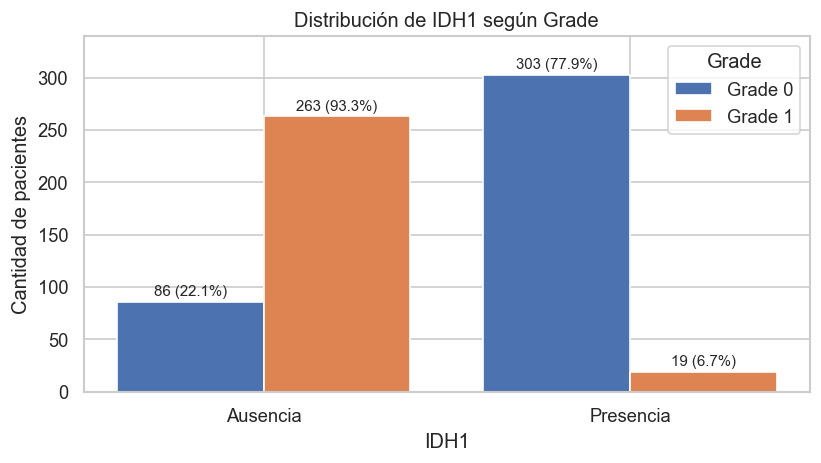
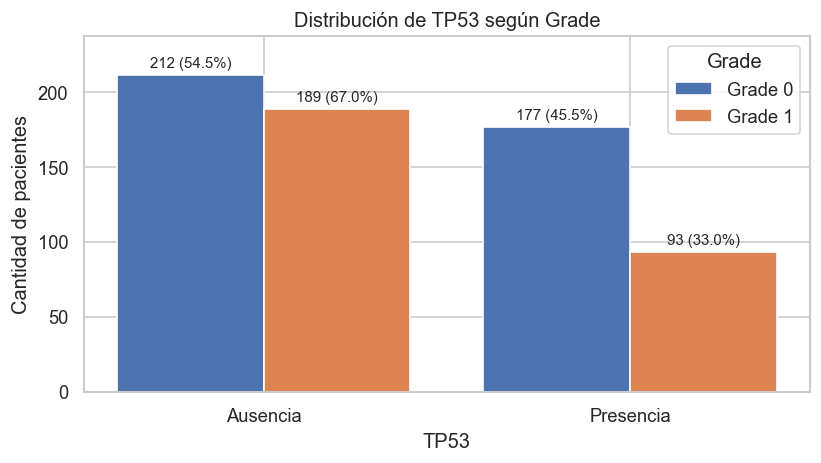
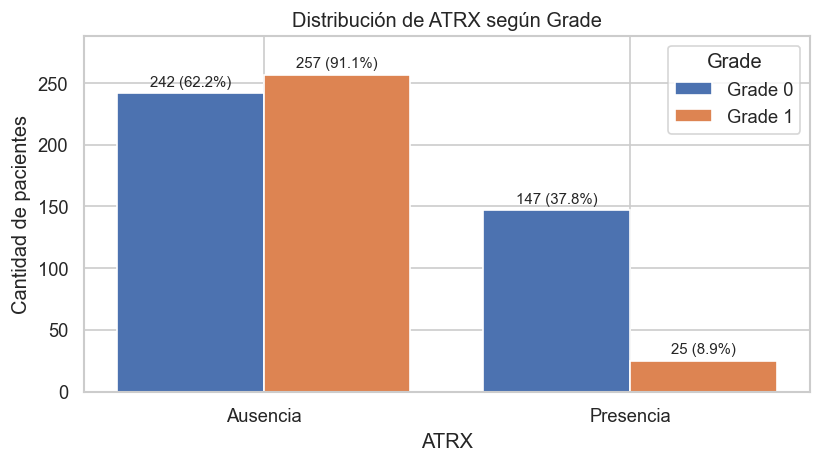
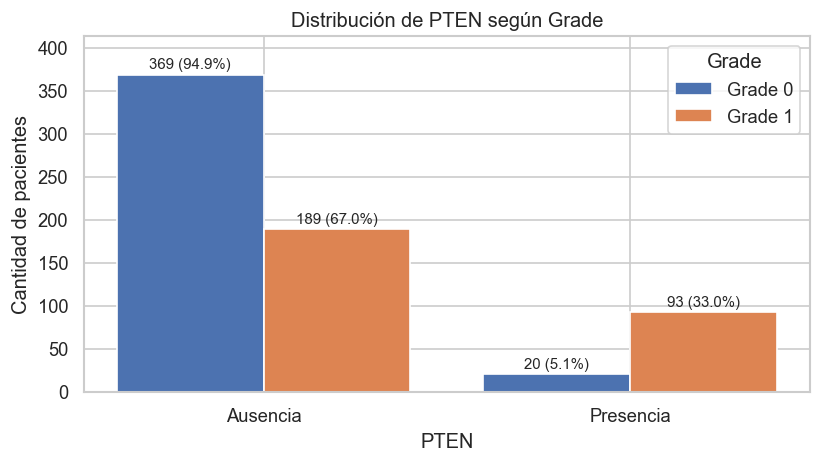
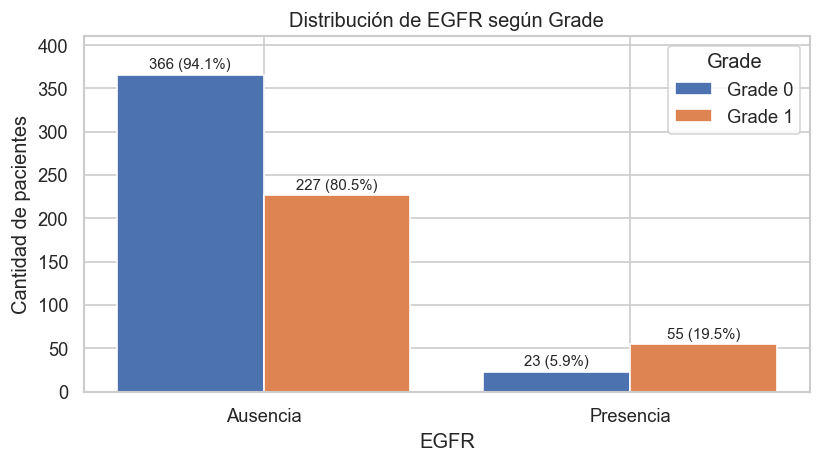
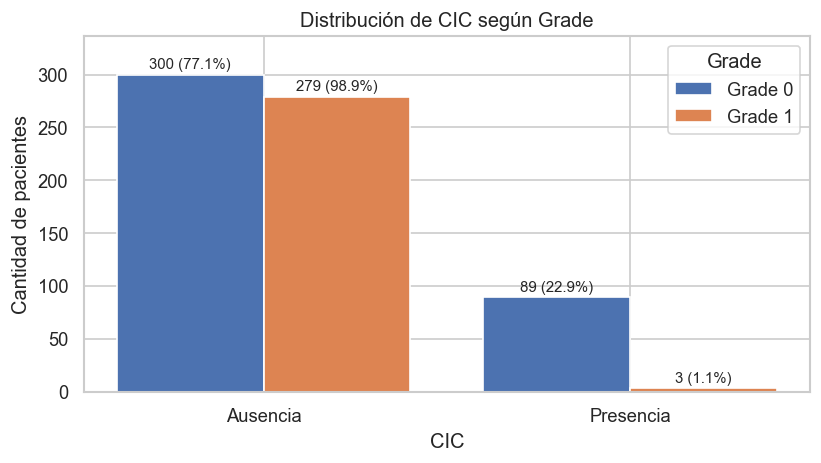
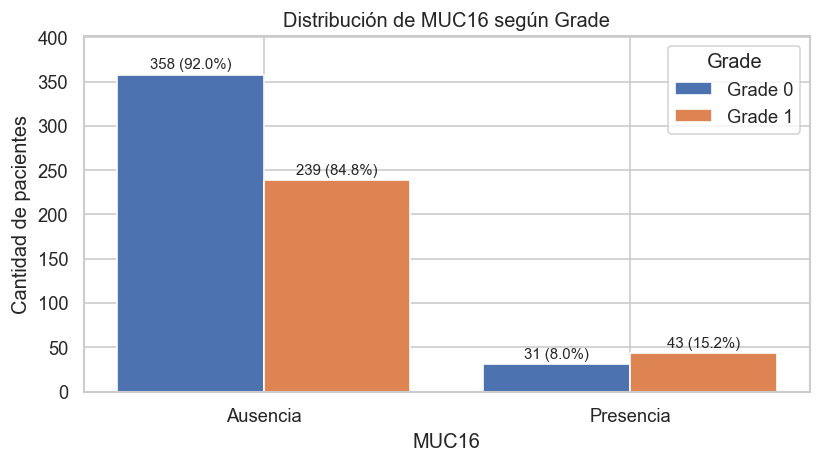
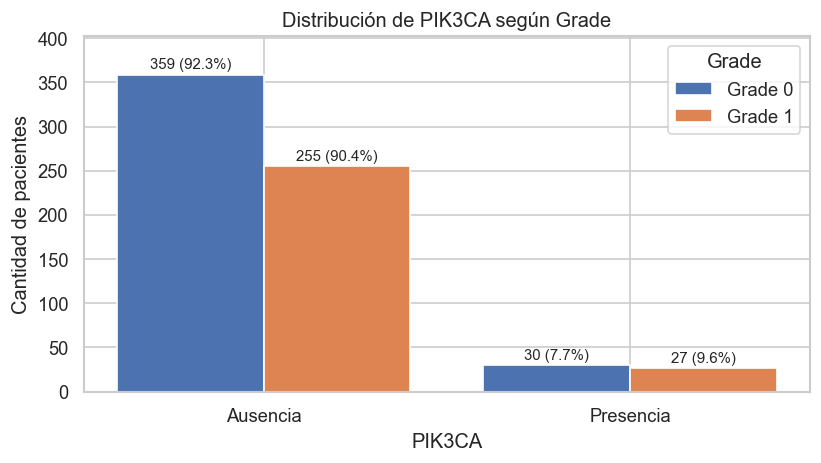
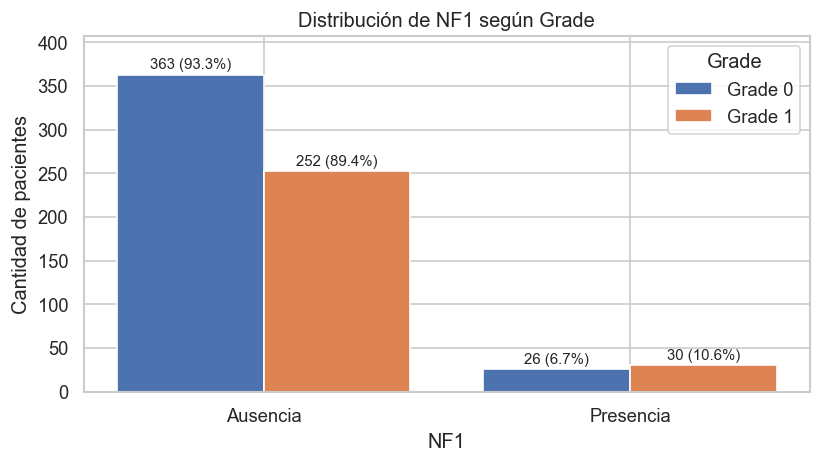
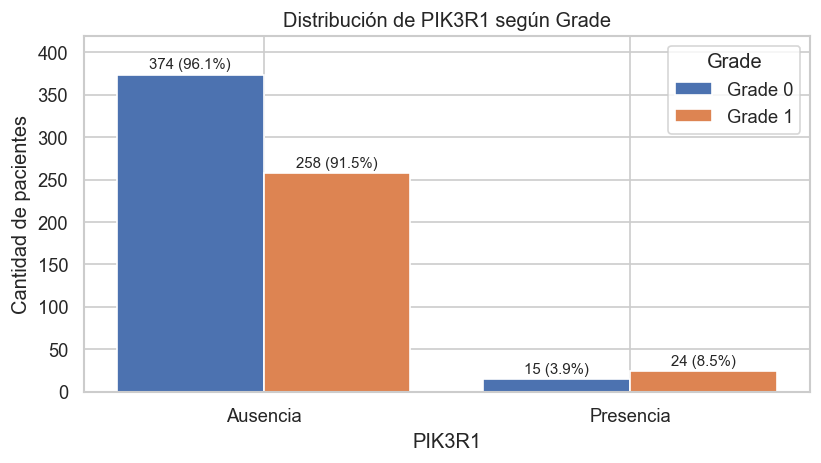
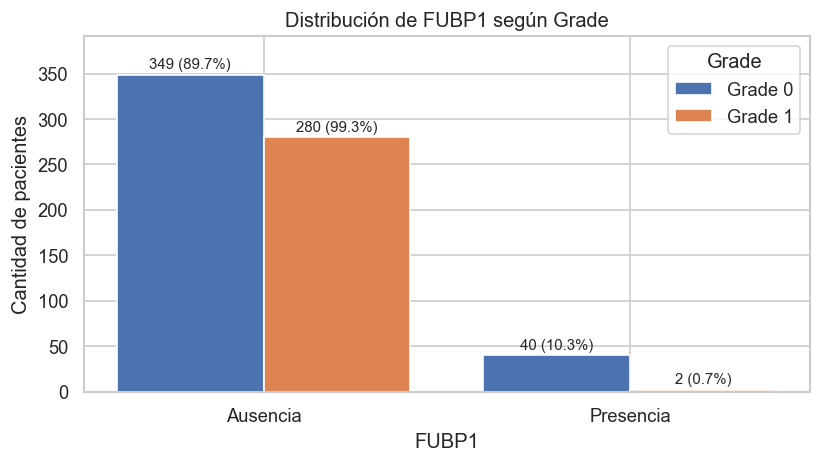
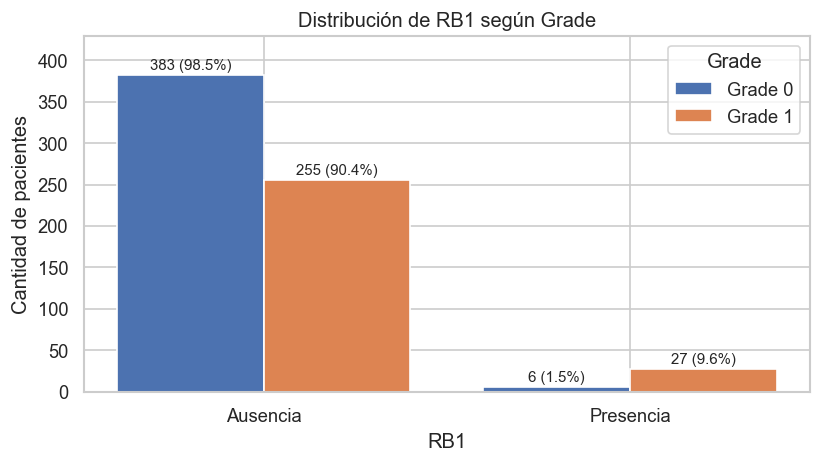
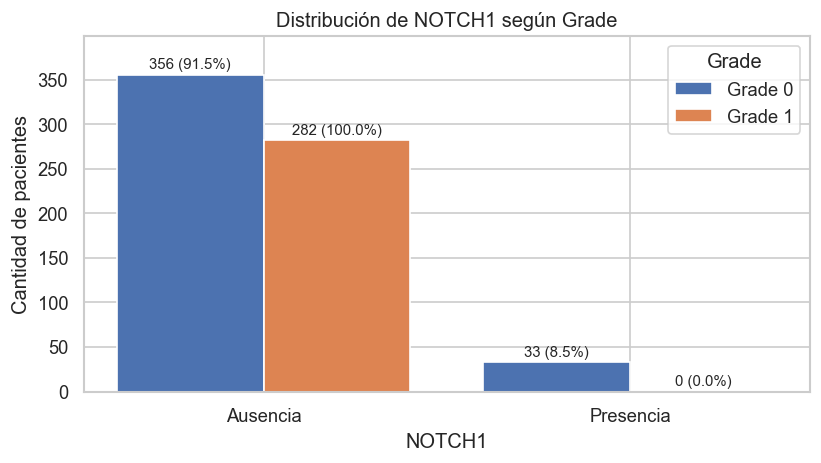
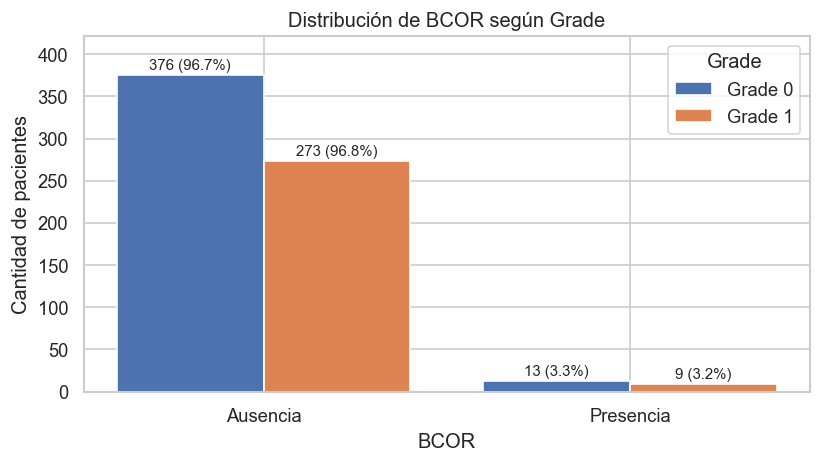
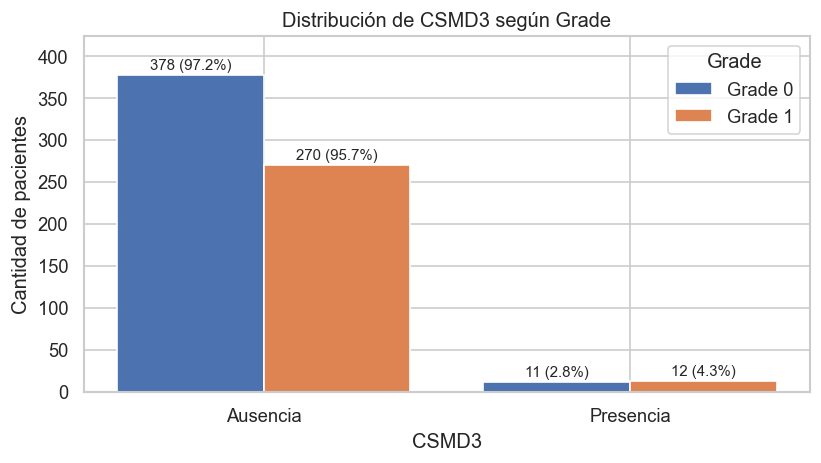
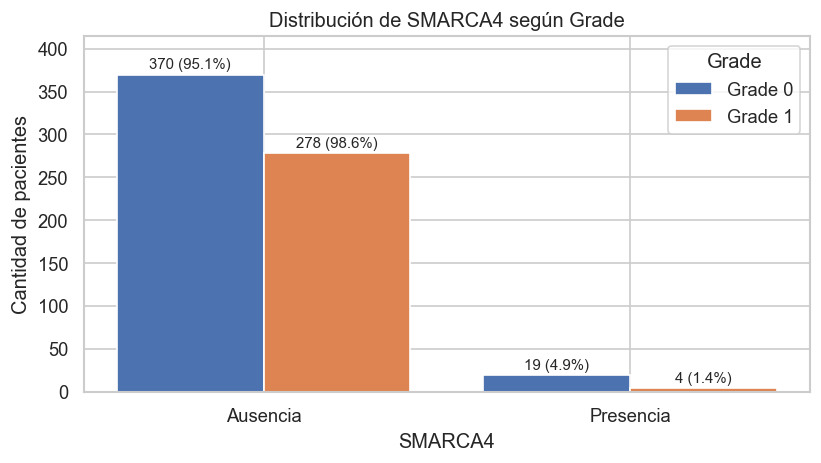
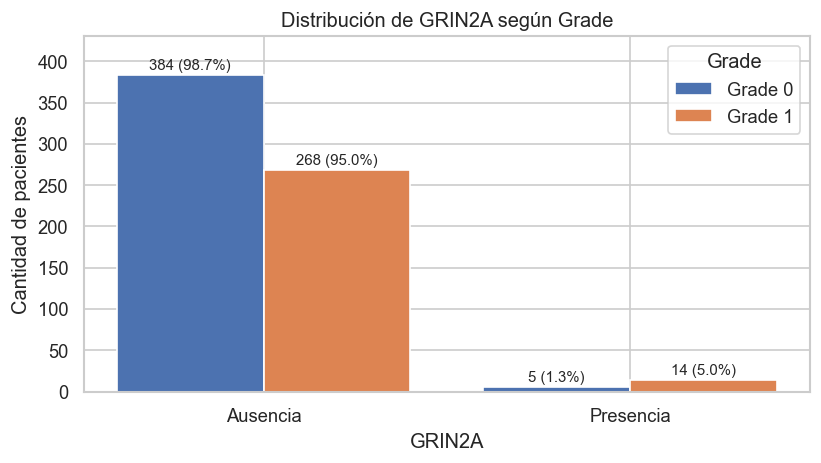
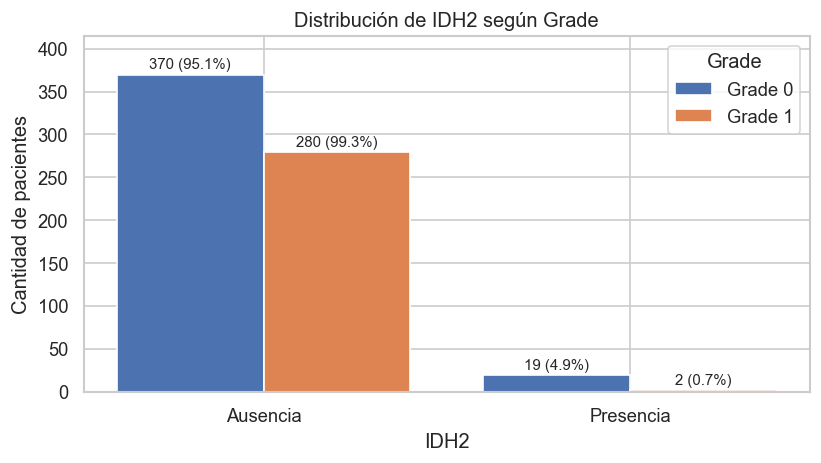
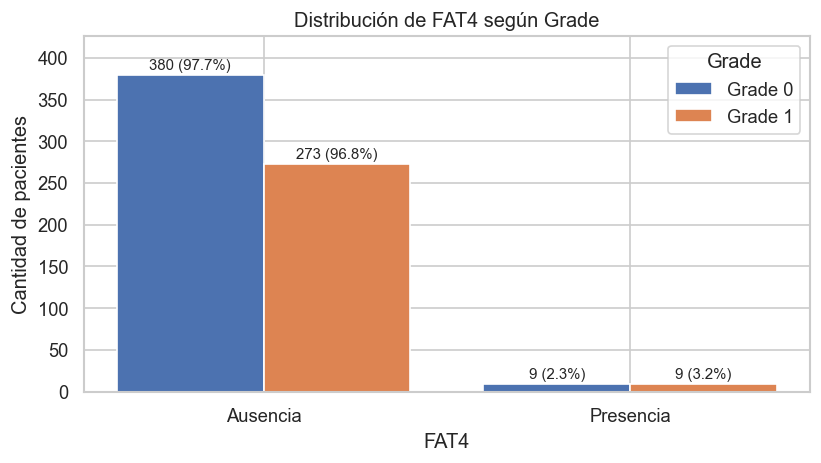
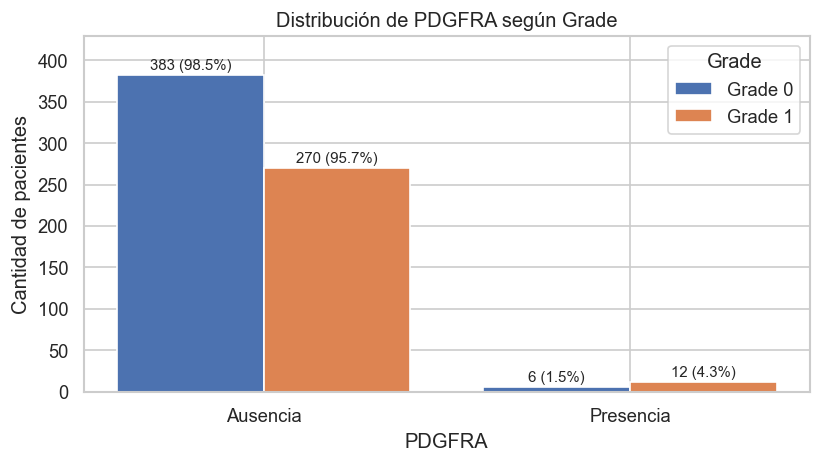

In [30]:
html_genes = f"""
<div style="
    margin-top: 20px;
">

    {html_idh1}
    {html_tp53}
    {html_atrx}
    {html_pten}
    {html_egfr}
    {html_cic}
    {html_muc16}
    {html_pik3ca}
    {html_nf1}
    {html_pik3r1}
    {html_fubp1}
    {html_rb1}
    {html_notch1}
    {html_bcor}
    {html_csm3}
    {html_smarca4}
    {html_grin2a}
    {html_idh2}
    {html_fat4}
    {html_pdgfra}

</div>
"""

display(HTML(html_genes))

### Multicolinealidad y correlación

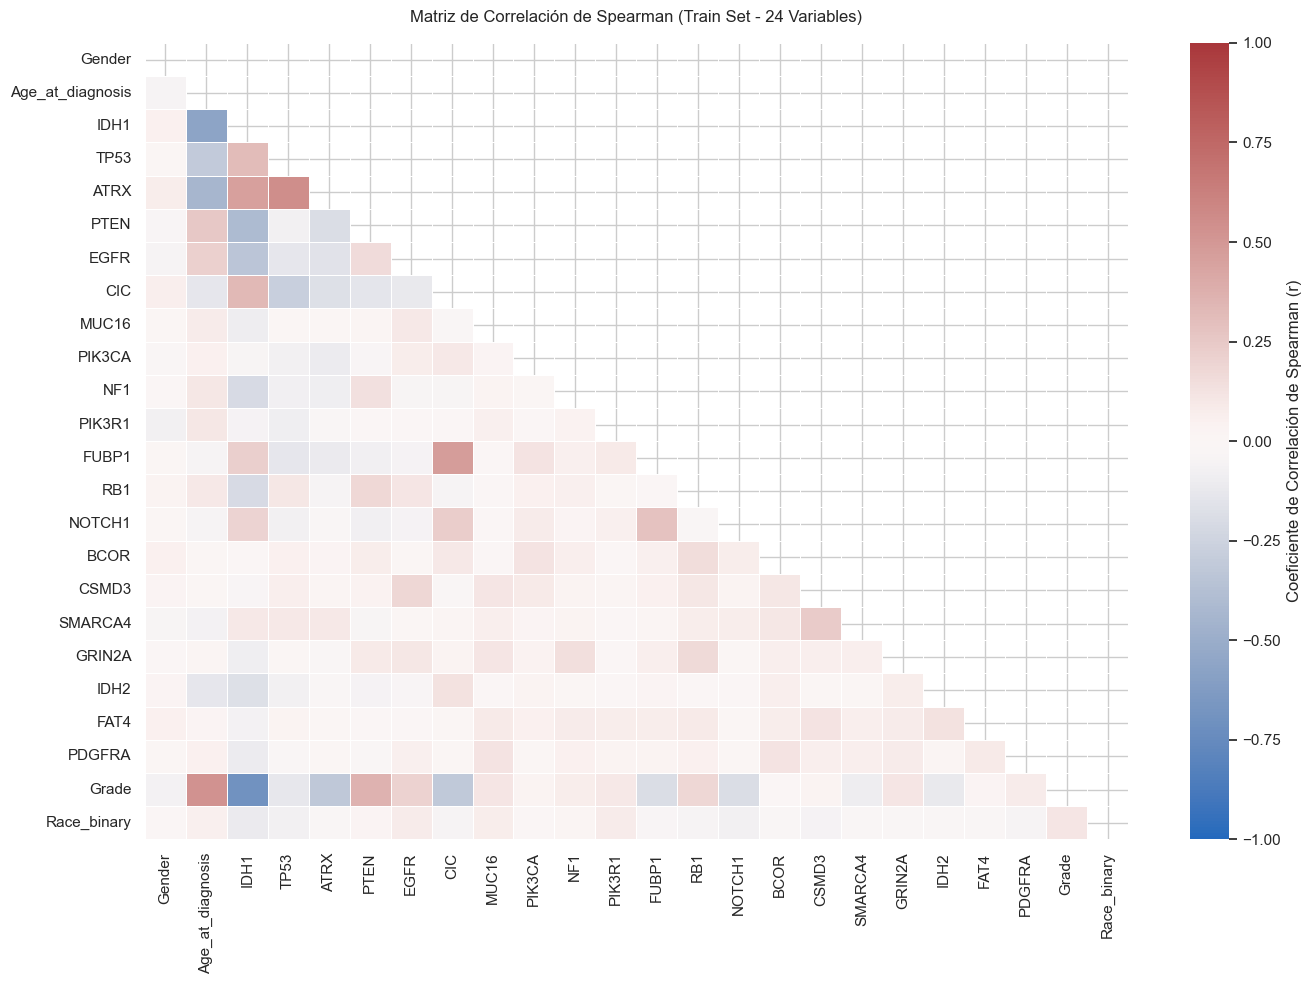

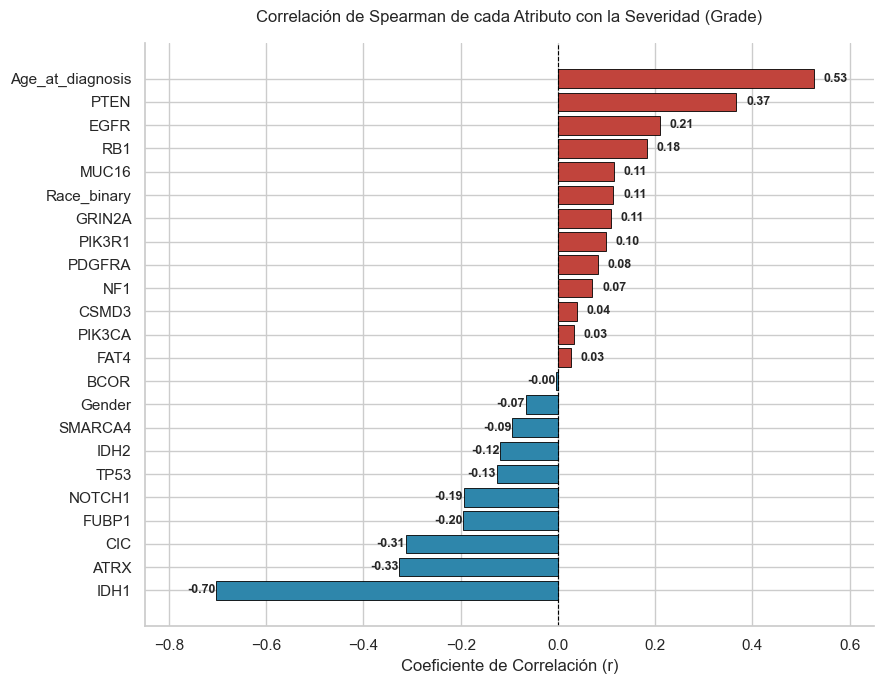

In [31]:
train_data['Race_binary'] = train_data['Race'].map({
    0: 0,  # White
    1: 1,  # Other racial groups
    2: 1,  # Other racial groups
    3: 1   # Other racial groups
})
train_data['Race_binary'] = train_data['Race_binary'].astype('category')
cols_spearman = [c for c in train_data.columns if c != 'Race']
spearman_corr = train_data[cols_spearman].corr(method='spearman')

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))

sns.heatmap(
    spearman_corr, 
    mask=mask,
    cmap='vlag', 
    vmax=1.0, 
    vmin=-1.0, 
    center=0,
    annot=False, 
    linewidths=0.5,
    cbar_kws={'label': 'Coeficiente de Correlación de Spearman (r)'}
)
plt.title(f'Matriz de Correlación de Spearman (Train Set - {spearman_corr.shape[0]} Variables)', pad=15)
plt.tight_layout()
plt.show()

target_corr = spearman_corr['Grade'].drop('Grade').sort_values(ascending=True)

plt.figure(figsize=(9, 7))
colors = [PALETTE_GRADE[0] if x < 0 else PALETTE_GRADE[1] for x in target_corr.values]

bars = plt.barh(target_corr.index, target_corr.values, color=colors, edgecolor='black', linewidth=0.6)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Correlación de Spearman de cada Atributo con la Severidad (Grade)', pad=15)
plt.xlabel('Coeficiente de Correlación (r)')
plt.xlim(-0.85, 0.65)

for bar in bars:
    width = bar.get_width()
    offset = 0.02 if width >= 0 else -0.06
    plt.text(
        width + offset, 
        bar.get_y() + bar.get_height()/2.0, 
        f'{width:.2f}', 
        va='center', 
        fontsize=9, 
        fontweight='bold'
    )

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [32]:
def phi_maximo(tabla):
    """Máximo |phi| alcanzable dadas las prevalencias marginales (solo 2x2)."""
    if tabla.shape != (2, 2):
        return np.nan
    n = tabla.sum()
    p1 = tabla[1, :].sum() / n
    p2 = tabla[:, 1].sum() / n
    a, b = min(p1, p2), max(p1, p2)
    if a in (0, 1) or b in (0, 1):
        return np.nan
    return np.sqrt((a * (1 - b)) / (b * (1 - a)))


def phi_signado(tabla):
    """Coeficiente phi con signo (solo 2x2)."""
    if tabla.shape != (2, 2):
        return np.nan
    a, b, c, d = tabla[0, 0], tabla[0, 1], tabla[1, 0], tabla[1, 1]
    den = np.sqrt(float((a + b) * (c + d) * (a + c) * (b + d)))
    return (a * d - b * c) / den if den > 0 else 0.0


def calcular_asociacion(x, y):
    tabla = pd.crosstab(x, y).to_numpy()

    chi2_c, p_chi2_c, dof, esperadas = chi2_contingency(tabla, correction=True)
    chi2_s, _, _, _ = chi2_contingency(tabla, correction=False)

    supuesto_valido = bool((esperadas >= 5).all())
    freq_esp_min = float(esperadas.min())

    # Fallback a Fisher exacto cuando el supuesto no se cumple
    if tabla.shape == (2, 2) and not supuesto_valido:
        _, p_val = fisher_exact(tabla)
        test = "Fisher exacto"
    else:
        p_val = p_chi2_c
        test = "Chi-cuadrado"

    # V de Cramér con corrección de Bergsma, sobre chi2 SIN Yates
    n = tabla.sum()
    phi2 = chi2_s / n
    r, k = tabla.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    den = min(kcorr - 1, rcorr - 1)
    v_cramer = float(np.sqrt(phi2corr / den)) if den > 0 else 0.0

    # phi normalizado por su techo teórico
    phi = phi_signado(tabla)
    pmax = phi_maximo(tabla)
    phi_norm = float(phi / pmax) if (pmax and not np.isnan(pmax) and pmax > 0) else np.nan

    return {
        "chi2": float(chi2_s), "p_value": float(p_val), "test": test,
        "v_cramer": v_cramer, "phi": float(phi),
        "phi_max": float(pmax) if not np.isnan(pmax) else np.nan,
        "phi_norm": phi_norm,
        "supuesto_valido": supuesto_valido, "freq_esp_min": freq_esp_min,
    }


# Excluimos 'Race' (4 categorías, frecuencias insuficientes); usamos 'Race_binary'
cat_cols = [c for c in train_data.columns if c not in ['Age_at_diagnosis', 'Race']]
n_cols = len(cat_cols)

cramer_matrix = pd.DataFrame(1.0, index=cat_cols, columns=cat_cols, dtype=float)
resultados_grade = []
resultados_pares = []

for i in range(n_cols):
    var1 = cat_cols[i]
    for j in range(i):
        var2 = cat_cols[j]
        r = calcular_asociacion(train_data[var1], train_data[var2])

        cramer_matrix.iloc[i, j] = r['v_cramer']
        cramer_matrix.iloc[j, i] = r['v_cramer']

        if 'Grade' in (var1, var2):
            otra = var2 if var1 == 'Grade' else var1
            resultados_grade.append({
                'Variable': otra,
                'Test': r['test'],
                'Chi2 (sin Yates)': round(r['chi2'], 2),
                'p-value': r['p_value'],
                'V de Cramer': round(r['v_cramer'], 4),
                'Supuesto OK': r['supuesto_valido'],
                'Freq. esp. min': round(r['freq_esp_min'], 2),
            })
        else:
            # TODOS los pares predictor-predictor conservan su diagnóstico
            resultados_pares.append({
                'Variable 1': var1,
                'Variable 2': var2,
                'Test': r['test'],
                'V de Cramer': round(r['v_cramer'], 4),
                'phi': round(r['phi'], 4),
                'phi max teórico': round(r['phi_max'], 4) if not np.isnan(r['phi_max']) else np.nan,
                'phi / phi max': round(r['phi_norm'], 4) if not np.isnan(r['phi_norm']) else np.nan,
                'p-value': r['p_value'],
                'Supuesto OK': r['supuesto_valido'],
                'Freq. esp. min': round(r['freq_esp_min'], 2),
            })

# ---------- corrección por comparaciones múltiples ----------

df_asociacion = pd.DataFrame(resultados_grade)
df_asociacion = df_asociacion.sort_values(by='V de Cramer', ascending=False)

df_pares = pd.DataFrame(resultados_pares)

def resaltar_supuesto(row):
    color = 'background-color: #fff3cd' if not row['Supuesto OK'] else ''
    return [color] * len(row)

print("ASOCIACIÓN CON GRADE (χ² / Fisher y V de Cramér)")

display(
    df_asociacion.style
    .hide(axis="index")
    .format({'p-value': '{:.6f}'})
    .apply(resaltar_supuesto, axis=1)
)

ASOCIACIÓN CON GRADE (χ² / Fisher y V de Cramér)


Variable,Test,Chi2 (sin Yates),p-value,V de Cramer,Supuesto OK,Freq. esp. min
IDH1,Chi-cuadrado,331.620000,0.000000,0.702500,True,135.330000
PTEN,Chi-cuadrado,90.460000,0.000000,0.365400,True,47.490000
ATRX,Chi-cuadrado,71.750000,0.000000,0.324900,True,72.290000
CIC,Chi-cuadrado,65.760000,0.000000,0.310900,True,38.660000
EGFR,Chi-cuadrado,29.390000,0.000000,0.205900,True,32.780000
FUBP1,Chi-cuadrado,25.540000,0.000001,0.191400,True,17.650000
NOTCH1,Chi-cuadrado,25.160000,0.000001,0.189900,True,13.870000
RB1,Chi-cuadrado,22.550000,0.000005,0.179400,True,13.870000
TP53,Chi-cuadrado,10.660000,0.001446,0.120100,True,113.470000
IDH2,Chi-cuadrado,9.400000,0.004493,0.112000,True,8.830000


In [33]:
UMBRAL_V = 0.40

df_pares_asociados = (
    df_pares[df_pares['V de Cramer'] > UMBRAL_V]
    .sort_values(by='V de Cramer', ascending=False)
)

print(f"\nPARES DE PREDICTORES CON ALTA ASOCIACIÓN MUTUA (V > {UMBRAL_V:.2f})")

if df_pares_asociados.empty:
    print(f"No se detectaron pares con V > {UMBRAL_V:.2f}.")
else:
    n_inval = (~df_pares_asociados['Supuesto OK']).sum()
    if n_inval:
        print(f"Atención: {n_inval} de estos pares NO cumplen el supuesto de "
              f"frecuencia esperada ≥ 5 (resaltados en amarillo).")
    display(
        df_pares_asociados.style
        .hide(axis="index")
        .format({'p-value': '{:.6f}', 'p-value (BH-FDR)': '{:.6f}'})
        .apply(resaltar_supuesto, axis=1)
    )


PARES DE PREDICTORES CON ALTA ASOCIACIÓN MUTUA (V > 0.40)


Variable 1,Variable 2,Test,V de Cramer,phi,phi max teórico,phi / phi max,p-value,Supuesto OK,Freq. esp. min
ATRX,TP53,Chi-cuadrado,0.547500,0.548400,0.715500,0.766500,0.000000,True,69.210000
FUBP1,CIC,Chi-cuadrado,0.468100,0.469400,0.648300,0.724100,0.000000,True,5.760000
ATRX,IDH1,Chi-cuadrado,0.459600,0.460900,0.611200,0.754100,0.000000,True,82.540000
PTEN,IDH1,Chi-cuadrado,0.406800,-0.408300,0.468500,-0.871600,0.000000,True,54.230000


In [34]:
UMBRAL_R = 0.70
UMBRAL_NORM = 0.70

print("DIAGNÓSTICO DE MULTICOLINEALIDAD ENTRE PREDICTORES")

n_inval = (~df_pares['Supuesto OK']).sum()
print(f"\n0) Validez de los contrastes entre predictores")
print(f"   • Pares evaluados: {len(df_pares)}")
print(f"   • Pares con frecuencia esperada < 5: {n_inval} "
      f"({n_inval/len(df_pares)*100:.1f}%) → resueltos con Fisher exacto")

pares_binarios = df_pares.dropna(subset=['phi max teórico'])
alcanzables = (pares_binarios['phi max teórico'] >= UMBRAL_R).sum()
total_bin = len(pares_binarios)

print(f"\n1) Viabilidad del umbral |r| > {UMBRAL_R:.2f}")
print(f"   • Pares binarios evaluados: {total_bin}")
print(f"   • Pares que PUEDEN alcanzar |phi| ≥ {UMBRAL_R:.2f}: {alcanzables} "
      f"({alcanzables/total_bin*100:.1f}%)")
print(f"   • Pares donde es matemáticamente IMPOSIBLE: {total_bin - alcanzables} "
      f"({(total_bin-alcanzables)/total_bin*100:.1f}%)")
print("   → Por desbalance de prevalencias, un umbral absoluto sobre |r| no es")
print("     un criterio informativo para la mayoría de los pares.")

pares_altos = []
columnas = spearman_corr.columns
for i in range(len(columnas)):
    for j in range(i):
        r_val = spearman_corr.iloc[i, j]
        if abs(r_val) > UMBRAL_R:
            pares_altos.append((columnas[i], columnas[j], round(r_val, 4)))

df_redundancias = pd.DataFrame(pares_altos, columns=['Variable 1', 'Variable 2', 'r'])
df_predictores_red = df_redundancias[
    (df_redundancias['Variable 1'] != 'Grade') &
    (df_redundancias['Variable 2'] != 'Grade')
]

print(f"\n2) Criterio absoluto |r| > {UMBRAL_R:.2f}")
if df_predictores_red.empty:
    print(f"   • Ningún par supera el umbral (resultado esperable, ver punto 1).")
else:
    print(df_predictores_red.to_string(index=False))

df_norm = df_pares.dropna(subset=['phi / phi max'])
red_norm = (
    df_norm[df_norm['phi / phi max'].abs() > UMBRAL_NORM]
    .sort_values(by='phi / phi max', key=abs, ascending=False)
)

print(f"\n3) Criterio normalizado |phi / phi_max| > {UMBRAL_NORM:.2f}")
print("   (corrige el techo impuesto por las prevalencias marginales)")
if red_norm.empty:
    print("   • No se detectaron pares con redundancia relativa alta.")
else:
    display(
        red_norm[['Variable 1', 'Variable 2', 'phi', 'phi max teórico',
                  'phi / phi max', 'V de Cramer', 'Supuesto OK']]
        .style.hide(axis="index").apply(resaltar_supuesto, axis=1)
    )

print(f"\n4) Criterio V de Cramér > {UMBRAL_V:.2f}: "
      f"{len(df_pares_asociados)} pares (ver celda anterior).")

DIAGNÓSTICO DE MULTICOLINEALIDAD ENTRE PREDICTORES

0) Validez de los contrastes entre predictores
   • Pares evaluados: 231
   • Pares con frecuencia esperada < 5: 130 (56.3%) → resueltos con Fisher exacto

1) Viabilidad del umbral |r| > 0.70
   • Pares binarios evaluados: 231
   • Pares que PUEDEN alcanzar |phi| ≥ 0.70: 87 (37.7%)
   • Pares donde es matemáticamente IMPOSIBLE: 144 (62.3%)
   → Por desbalance de prevalencias, un umbral absoluto sobre |r| no es
     un criterio informativo para la mayoría de los pares.

2) Criterio absoluto |r| > 0.70
   • Ningún par supera el umbral (resultado esperable, ver punto 1).

3) Criterio normalizado |phi / phi_max| > 0.70
   (corrige el techo impuesto por las prevalencias marginales)


Variable 1,Variable 2,phi,phi max teórico,phi / phi max,V de Cramer,Supuesto OK
IDH2,IDH1,-0.172700,0.187100,-0.922600,0.168400,True
EGFR,IDH1,-0.339100,0.377600,-0.898000,0.337100,True
PTEN,IDH1,-0.408300,0.468500,-0.871600,0.406800,True
RB1,IDH1,-0.204700,0.236800,-0.864400,0.201100,True
NOTCH1,IDH1,0.195400,0.236800,0.825200,0.191700,True
FUBP1,IDH1,0.219800,0.269000,0.816900,0.216500,True
CIC,IDH1,0.328300,0.415000,0.791000,0.326200,True
ATRX,TP53,0.548400,0.715500,0.766500,0.547500,True
ATRX,IDH1,0.460900,0.611200,0.754100,0.459600,True
FUBP1,CIC,0.469400,0.648300,0.724100,0.468100,True



4) Criterio V de Cramér > 0.40: 4 pares (ver celda anterior).


El análisis bivariado y de correlación de Spearman sobre el conjunto de entrenamiento ($n = 671$) revela asociaciones clínico-moleculares altamente discriminantes entre Gliomas de Bajo Grado (LGG) y Glioblastoma Multiforme (GBM):

**Asociaciones Individuales con la Severidad Tumoral (`Grade`):**
* **Biomarcadores Protectores (Asociados a LGG):** La mutación en el gen **`IDH1`** constituye el factor molecular con mayor capacidad discriminativa e inversa respecto a la malignidad ($r = -0,70$, $V \approx 0,70$, $p < 0,001$), seguida por alteraciones en **`ATRX`** ($r = -0,33$, $V \approx 0,32$) y **`CIC`** ($r = -0,31$, $V \approx 0,31$).
* **Indicadores de Riesgo (Asociados a GBM):** La variable **`Age_at_diagnosis`** representa el principal correlato clínico directo con la severidad ($r = +0,53$), confirmando la mayor prevalencia de GBM en edades avanzadas. A nivel genómico, **`PTEN`** destaca como el marcador de riesgo más sólido ($V = 0,3613$, $r = +0,37$), seguido por **`EGFR`** ($V = 0,2011$, $r = +0,21$) y **`RB1`** ($V = 0,1722$, $r = +0,18$).
* **Variables No Significativas:** Las variables con $p > 0,05$ en Chi-cuadrado, valores de $V < 0,08$ y magnitudes de $\vert{}r\vert{} < 0,10$ (como `PDGFRA`, `NF1`, `Gender`, `CSMD3`, `BCOR`, `PIK3CA` y `FAT4`) aportan una varianza explicativa insignificante, respaldando su eliminación para simplificar el modelo predictivo y reducir costos diagnósticos.


**Arquitectura de Interacción Inter-Genómica ($V > 0,40$):**
* **Patrones de Co-ocurrencia:** El par **`ATRX`–`TP53`** presenta la mayor fuerza de asociación mutua ($V = 0,5440$), reflejando el eje de co-mutación clásico en la astrocitogénesis. Las interacciones **`FUBP1`–`CIC`** ($V = 0,4592$) y **`ATRX`–`IDH1`** ($V = 0,4562$) reafirman las firmas genómicas del linaje oligodendroglial y de gliomas de bajo grado.
* **Exclusión Mutua:** La relación entre **`PTEN`** e **`IDH1`** ($V = 0,4028$) responde a una regla de incompatibilidad biológica asociada al grado tumoral (`IDH1` mutado en LGG vs. `PTEN` alterado en GBM).

**Diagnóstico de Multicolinealidad para el Modelado Predictivo:**
El umbral convencional de $\vert r \vert > 0,70$ resulta poco informativo en este conjunto de datos: debido al fuerte desbalance de prevalencias entre genes, en **115 de los 190 pares (60,5%) dicho valor es matemáticamente inalcanzable**. Por ejemplo, el par `IDH1`–`FAT4` (prevalencias 47,99% y 2,68%) tiene un techo teórico de $\vert \phi \vert_{max} = 0,173$. Por ello, el diagnóstico se complementó con la $V$ de Cramér y con $\phi$ normalizado por su máximo teórico. Bajo estos criterios **no se detectó redundancia severa entre predictores**, si bien los pares de co-ocurrencia señalados ($V \approx 0,40$–$0,54$) representan estructura biológica real que los algoritmos deberán absorber. Adicionalmente, el **62,6% de los pares gen×gen incumple el supuesto de frecuencia esperada $\geq 5$**, por lo que dichos contrastes se resolvieron mediante la prueba exacta de Fisher y aparecen señalizados en las tablas correspondientes.

In [35]:
# Transferencia de datos

with open("datos_modelado.pkl", "wb") as f:
    pickle.dump({
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }, f)